Regress on year, game, age with a dummy variable that holds 1 to cumsum the amount of games they've played that year, and y shoiuld be accumulated BPM


Can also groupby injury times rather than type\
if idx + 1 is the same column for acquired, drop the second row


## Merging the datasets


In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)
# use acquired and relinquished for going on IL vs going off IL
injuries = pd.read_csv("./data/injuries.csv")
injuries = injuries.drop(columns=["Unnamed: 0"])
injuries

,Date,Team,Acquired,Relinquished,Notes
0,1951-12-25,Bullets,NaN,Don Barksdale,placed on IL
1,1952-12-26,Knicks,NaN,Max Zaslofsky,placed on IL with torn side muscle
2,1956-12-29,Knicks,NaN,Jim Baechtold,placed on inactive list
3,1959-01-16,Lakers,NaN,Elgin Baylor,player refused to play after being denied a ro...
4,1961-11-26,Lakers,NaN,Elgin Baylor,player reported for military duty
...,...,...,...,...,...
37662,2023-04-16,Clippers,Marcus Morris,NaN,activated from IL
37663,2023-04-16,Grizzlies,Dillon Brooks,NaN,activated from IL
37664,2023-04-16,Grizzlies,Ja Morant,NaN,activated from IL
37665,2023-04-16,Grizzlies,Jaren Jackson Jr.,NaN,activated from IL


In [2]:
injuries = injuries.query("Date >= '2001-07-01'")
# injuries.to_csv("injuries_recent.csv", index=False)

In [3]:
injuries["Relinquished"] = injuries["Relinquished"].str.strip()
injuries["Acquired"] = injuries["Acquired"].str.strip()

/var/folders/v7/1_gf4cd15qgd59psn6gym7_r0000gn/T/ipykernel_90636/3260738829.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  injuries["Relinquished"] = injuries["Relinquished"].str.strip()
/var/folders/v7/1_gf4cd15qgd59psn6gym7_r0000gn/T/ipykernel_90636/3260738829.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  injuries["Acquired"] = injuries["Acquired"].str.strip()


In [4]:
injuries.query(
    "Relinquished == 'Klay Thompson' or Acquired == 'Klay Thompson'"
).reset_index(drop=True).to_csv("temp.csv")
# if idx + 1 is the same column for acquired, drop the second row

In [5]:
df = pd.read_csv("./Data/regular_season_bpm.csv", dtype={56: str})
df

,game_id,season,season_type,game_date,game_date_time,athlete_id,athlete_display_name,team_id,team_name,team_location,team_short_display_name,minutes,fgm,fga,3pm,3pa,ftm,fta,orb,drb,rebounds,assists,steals,blocks,turnovers,fouls,plus_minus,points,starter,ejected,did_not_play,active,athlete_jersey,athlete_short_name,athlete_headshot_href,athlete_position_name,athlete_position_abbreviation,team_display_name,team_uid,team_slug,team_logo,team_abbreviation,team_color,team_alternate_color,home_away,team_winner,team_score,opponent_team_id,opponent_team_name,opponent_team_location,opponent_team_display_name,opponent_team_abbreviation,opponent_team_logo,opponent_team_color,opponent_team_alternate_color,opponent_team_score,reason,season_team,season_type_team,game_date_team,game_date_time_team,team_uid_team,team_slug_team,team_location_team,team_name_team,team_abbreviation_team,team_display_name_team,team_short_display_name_team,team_color_team,team_alternate_color_team,team_logo_team,team_home_away,points_team,team_winner_team,assists_team,blocks_team,defensive_rebounds_team,fast_break_points,field_goal_pct,field_goals_made_team,fga_team,flagrant_fouls,fouls_team,free_throw_pct,free_throws_made_team,fta_team,orb_team,points_in_paint,steals_team,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made_team,three_point_field_goals_attempted_team,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,tov_team,opponent_team_id_team,opponent_team_uid,opponent_team_slug,opponent_team_location_team,opponent_team_name_team,opponent_team_abbreviation_team,opponent_team_display_name_team,opponent_team_short_display_name,opponent_team_color_team,opponent_team_alternate_color_team,opponent_team_logo_team,opponent_team_score_team,largest_lead,possessions_team,minutes_team,possessions,points_per_100_possessions,3pm_per_100_possessions,assists_per_100_possessions,turnovers_per_100_possessions,orb_per_100_possessions,drb_per_100_possessions,steals_per_100_possessions,blocks_per_100_possessions,fouls_per_100_possessions,fga_per_100_possessions,fta_per_100_possessions,raw_bpm,minutes_z_score_player_season,season_avg_minutes,team_adjustment,adjusted_team_efficiency,adjusted_bpm,raw_bpm*mins,bpm*mins,cumulative_raw_bpm_contribution,cumulative_bpm_contribution,average_bpm_contribution,avg*mins,cumulative_average_bpm_contribution,final_average_bpm_contribution,cumulative_average_z_score_player_season
0,211030019,2002,2,2001-10-30,2001-10-31T00:30:00Z,353.0,Troy Hudson,19,Magic,Orlando,Magic,19.0,6.0,11.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,0.0,3.0,3.0,0,12.0,False,False,False,False,6.0,T. Hudson,NaN,Point Guard,PG,Orlando Magic,s:40~l:46~t:19,orlando-magic,https://a.espncdn.com/i/teamlogos/nba/500/orl.png,ORL,0860A8,c4ced3,home,True,114,28,Raptors,Toronto,Toronto Raptors,TOR,https://a.espncdn.com/i/teamlogos/nba/500/tor.png,CE0F41,061922,85,NaN,2002.0,2.0,2001-10-30,2001-10-31T00:30:00Z,s:40~l:46~t:19,orlando-magic,Orlando,Magic,ORL,Orlando Magic,Magic,0860A8,c4ced3,https://a.espncdn.com/i/teamlogos/nba/500/orl.png,home,114.0,True,23.0,7.0,27.0,9.0,61.1,44.0,72.0,0.0,31.0,71.0,22.0,31.0,10.0,-1.0,12.0,19.0,1.0,50.0,4.0,8.0,47.0,1.0,38.0,23.0,19.0,28.0,s:40~l:46~t:28,toronto-raptors,Toronto,Raptors,TOR,Toronto Raptors,Raptors,CE0F41,061922,https://a.espncdn.com/i/teamlogos/nba/500/tor.png,85.0,NaN,94.64,48.0,37,32.43,0.00,5.41,8.11,0.00,5.41,0.00,0.00,8.11,29.73,0.00,0.619950,-0.447828,23.542169,-6.820928,2.758450,-6.200978,11.779050,-117.818582,0.619950,-6.200978,-2.790514,-53.019766,-2.790514,3.514053,-1.761281
1,211030023,2002,2,2001-10-30,2001-10-31T00:00:00Z,376.0,Bobby Jackson,23,Kings,Sacramento,Kings,19.0,3.0,4.0,1.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,2.0,5.0,0,7.0,False,False,False,False,24.0,B. Jackson,NaN,Point Guard,PG,Sacramento Kings,s:40~l:46~t:23,sacramento-kings,https://a.espncdn.com/i/teamlogos/nba/500/sac.png,SAC,393996,8e9090,home,True,101,25,SuperSonics,Seattle,Seattle SuperSonics,SEA,NaN,1C3F2C

In [6]:
player_bpm = pd.read_csv("./data/player_bpm_results.csv")
player_bpm

,game_id,season,athlete_id,athlete_display_name,team_id,team_name,position,offensive_role,minutes,BPM,OBPM,DBPM,Game_VORP,Game_WOR,points,assists,rebounds,steals,blocks,turnovers,BPM*min,season_bpm
0,211030019,2002,353.0,Troy Hudson,19,Magic,1.860991,4.136764,19.0,4.799162,4.311001,0.488160,0.006564,0.017723,12.0,2.0,2.0,0.0,0.0,3.0,91.184069,-1.252180
1,211030019,2002,1002.0,Steven Hunter,19,Magic,2.797475,5.000000,4.0,5.772692,3.770132,2.002560,0.001580,0.004266,2.0,0.0,1.0,0.0,0.0,0.0,23.090769,-2.171278
2,211030019,2002,196.0,Andrew DeClercq,19,Magic,2.774498,5.000000,12.0,10.100595,3.569235,6.531360,0.007378,0.019922,3.0,2.0,3.0,3.0,0.0,1.0,121.207144,-2.290156
3,211030019,2002,336.0,Grant Hill,19,Magic,2.394825,5.000000,32.0,12.166167,8.911927,3.254240,0.023034,0.062193,22.0,5.0,3.0,0.0,0.0,4.0,389.317347,1.453543
4,211030019,2002,279.0,Horace Grant,19,Magic,3.266647,4.971434,29.0,13.253666,9.049417,4.204249,0.022477,0.060689,12.0,2.0,6.0,1.0,0.0,0.0,384.356309,0.099380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757391,401704774,2025,4397014.0,Quentin Grimes,6,Mavericks,2.412926,4.289560,0.0,-10.036299,-11.012095,0.975796,-0.000000,-0.000000,0.0,0.0,0.0,0.0,0.0,0.0,-0.000000,-0.643819
757392,401704774,2025,4278049.0,Daniel Gafford,6,Mavericks,3.406428,4.834281,34.0,1.576170,-5.784633,7.360803,0.006178,0.016682,16.0,3.0,7.0,2.0,2.0,1.0,53.589791,1.852320
757393,401704774,2025,4868423.0,Jaden Hardy,6,Mavericks,2.223501,5.000000,19.0,-10.029843,-11.623875,1.594032,-0.007752,-0.020931,2.0,3.0,2.0,1.0,0.0,1.0,-190.567022,-3.505307
757394,401704774,2025,4397040.0,Brandon Williams,6,Mavericks,2.174701,5.000000,0.0,-8.953484,-10.504352,1.550868,-0.000000,-0.000000,0.0,0.0,0.0,0.0,0.0,0.0,-0.000000,-1.753312


In [7]:
player_bpm = player_bpm.rename(columns={"position": "calculated_position"})[
    [
        "game_id",
        "season",
        "athlete_id",
        "athlete_display_name",
        "calculated_position",
        "BPM",
        "season_bpm",
    ]
]
df = df.merge(
    player_bpm,
    how="left",
    on=["game_id", "season", "athlete_id", "athlete_display_name"],
).rename(columns={"BPM": "bpm"})

In [8]:
df.sort_values(by=["season_bpm"], ascending=False).drop_duplicates(
    subset=["athlete_display_name", "season"]
).loc[
    df.groupby(["athlete_display_name", "season"])["minutes"].transform("sum") > 1000
].reset_index(
    drop=True
).head(
    10
)

,game_id,season,season_type,game_date,game_date_time,athlete_id,athlete_display_name,team_id,team_name,team_location,team_short_display_name,minutes,fgm,fga,3pm,3pa,ftm,fta,orb,drb,rebounds,assists,steals,blocks,turnovers,fouls,plus_minus,points,starter,ejected,did_not_play,active,athlete_jersey,athlete_short_name,athlete_headshot_href,athlete_position_name,athlete_position_abbreviation,team_display_name,team_uid,team_slug,team_logo,team_abbreviation,team_color,team_alternate_color,home_away,team_winner,team_score,opponent_team_id,opponent_team_name,opponent_team_location,opponent_team_display_name,opponent_team_abbreviation,opponent_team_logo,opponent_team_color,opponent_team_alternate_color,opponent_team_score,reason,season_team,season_type_team,game_date_team,game_date_time_team,team_uid_team,team_slug_team,team_location_team,team_name_team,team_abbreviation_team,team_display_name_team,team_short_display_name_team,team_color_team,team_alternate_color_team,team_logo_team,team_home_away,points_team,team_winner_team,assists_team,blocks_team,defensive_rebounds_team,fast_break_points,field_goal_pct,field_goals_made_team,fga_team,flagrant_fouls,fouls_team,free_throw_pct,free_throws_made_team,fta_team,orb_team,points_in_paint,steals_team,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made_team,three_point_field_goals_attempted_team,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,tov_team,opponent_team_id_team,opponent_team_uid,opponent_team_slug,opponent_team_location_team,opponent_team_name_team,opponent_team_abbreviation_team,opponent_team_display_name_team,opponent_team_short_display_name,opponent_team_color_team,opponent_team_alternate_color_team,opponent_team_logo_team,opponent_team_score_team,largest_lead,possessions_team,minutes_team,possessions,points_per_100_possessions,3pm_per_100_possessions,assists_per_100_possessions,turnovers_per_100_possessions,orb_per_100_possessions,drb_per_100_possessions,steals_per_100_possessions,blocks_per_100_possessions,fouls_per_100_possessions,fga_per_100_possessions,fta_per_100_possessions,raw_bpm,minutes_z_score_player_season,season_avg_minutes,team_adjustment,adjusted_team_efficiency,adjusted_bpm,raw_bpm*mins,bpm*mins,cumulative_raw_bpm_contribution,cumulative_bpm_contribution,average_bpm_contribution,avg*mins,cumulative_average_bpm_contribution,final_average_bpm_contribution,cumulative_average_z_score_player_season,calculated_position,bpm,season_bpm
0,281219007,2009,2,2008-12-19,2008-12-20T03:30:00Z,1966.0,LeBron James,5,Cavaliers,Cleveland,Cavaliers,39.0,13.0,20.0,0.0,2.0,7.0,8.0,3.0,7.0,10.0,8.0,0.0,0.0,6.0,3.0,14,33.0,True,False,False,False,6.0,L. James,https://a.espncdn.com/i/headshots/nba/players/...,Small Forward,SF,Cleveland Cavaliers,s:40~l:46~t:5,cleveland-cavaliers,https://a.espncdn.com/i/teamlogos/nba/500/cle.png,CLE,061642,fdbb30,away,True,105,7,Nuggets,Denver,Denver Nuggets,DEN,https://a.espncdn.com/i/teamlogos/nba/500/den.png,0860A8,fdb927,88,NaN,2009.0,2.0,2008-12-19,2008-12-20T03:30:00Z,s:40~l:46~t:5,cleveland-cavaliers,Cleveland,Cavaliers,CLE,Cleveland Cavaliers,Cavaliers,061642,fdbb30,https://a.espncdn.com/i/teamlogos/nba/500/cle.png,away,105.0,True,23.0,4.0,32.0,14.0,47.6,40.0,84.0,1.0,23.0,79.2,19.0,24.0,11.0,0.0,8.0,13.0,1.0,30.0,6.0,20.0,52.0,1.0,26.0,18.0,13.0,7.0,s:40~l:46~t:7,denver-nuggets,Denver,Nuggets,DEN,Denver Nuggets,Nuggets,0860A8,fdb927,https://a.espncdn.com/i/teamlogos/nba/500/den.png,88.0,22.0,96.56,48.4,78,42.31,0.00,10.26,7.69,3.85,8.97,0.00,0.00,3.85,25.64,10.26,18.500435,0.170669,38.284211,-6.173788,4.349122,12.326647,721.516965,480.739216,22.757752,16.583964,15.413541,601.128091,19.670858,19.591328,4.056723,2.294081,13.505274,12.642089
1,400828268,2016,2,2015-12-16,2015-12-17T03:30:00Z,3975.0,Stephen Curry,9,Warriors,Golden State,Warriors,30.0,10.0,14.0,2.0,5.0,3.0,5.0,0.0,2.0,2.0,7.0,1.0,0.0,3.0,4.0,37,25.0,True,False,False,False,30.0,S. Curry,https://a.espncdn.com/i/headshots/nba/players/

In [9]:
df = df.query(
    "team_name not in ['All-Stars', 'Team LeBron', 'Team Giannis', 'World', 'USA', 'Team Stephen', 'Team Candace', 'Team Shaq', 'Team Durant', 'Team Kenny']"
)

In [10]:
df.to_csv("./data/merged_bpm_data.csv", index=False)

Since none has same team and player, just merge on player and team


In [11]:
# Find athlete names that have multiple different athlete_ids
name_id_mapping = df.groupby("athlete_display_name")["athlete_id"].nunique()
names_with_multiple_ids = name_id_mapping[name_id_mapping > 1].index

# Show the actual records for these problematic names
problematic_records = (
    df[df["athlete_display_name"].isin(names_with_multiple_ids)][
        ["athlete_display_name", "athlete_id", "team_name"]
    ]
    .drop_duplicates(subset=["athlete_display_name", "athlete_id"])
    .sort_values("athlete_display_name")
)

print(f"Found {len(names_with_multiple_ids)} athlete names with multiple IDs:")
problematic_records

Found 5 athlete names with multiple IDs:


,athlete_display_name,athlete_id,team_name
192313,Chris Johnson,4400.0,Trail Blazers
229128,Chris Johnson,2325975.0,Grizzlies
119336,Corey Brewer,3191.0,Timberwolves
360794,Corey Brewer,4415554.0,76ers
15213,Dee Brown,97.0,Magic
99457,Dee Brown,2994.0,Jazz
257761,Isaiah Canaan,2490589.0,Rockets
348457,Isaiah Canaan,4412182.0,Suns
7047,Mike James,1051.0,Heat
326568,Mike James,2528096.0,Suns


In [12]:
gpt_injury_data = pd.read_csv("./Data/cleaned_injuries_recent2.csv")
gpt_injury_data["Player"] = gpt_injury_data["Player"].str.strip()
gpt_injury_data

,Player,Date,Team,Injury,Injury Category
0,Sam Clancy,2002-10-28,76ers,left knee injury,Knee (Minor)
1,Charles Smith (Cornelius),2002-10-28,Blazers,sore left hip,Hip
2,Chris Dudley,2002-10-28,Blazers,left side sacroliac pain,Other
3,Ruben Boumtje Boumtje,2002-10-28,Blazers,sore right knee,Knee (Minor)
4,Jamal Sampson,2002-10-28,Bucks,chronic left ankle pain,Ankle (Sprain/Fracture)
...,...,...,...,...,...
10242,Ja Morant,2023-04-09,Grizzlies,right hand injury,Hand
10243,Jaren Jackson Jr.,2023-04-09,Grizzlies,sore left elbow,Other
10244,Davion Mitchell,2023-04-09,Kings,sore left knee,Knee (Minor)
10245,Trevor Keels,2023-04-09,Knicks,illness,Illness (non-COVID)


In [13]:
merged_injuries = injuries.merge(
    gpt_injury_data,
    left_on=["Relinquished", "Date"],
    right_on=["Player", "Date"],
    how="left",
)

merged_injuries["Injury"].value_counts()

Injury
NBA health and safety protocols                          522
sprained left ankle                                      513
illness                                                  502
sprained right ankle                                     479
sore left knee                                           269
                                                        ... 
fractured frontal bone (out for season)                    1
back spasms / herniated disc in back (out for season)      1
muscle strain in lower right leg                           1
knee injury / rest (out for season)                        1
stitches in left foot                                      1
Name: count, Length: 1650, dtype: int64

BPM\*min should accumulate by period, then divide by games


In [14]:
merged_injuries["Injury Category"].value_counts()

Injury Category
Other                      1867
Knee (Minor)               1769
Ankle (Sprain/Fracture)    1612
Back                        817
Illness (non-COVID)         543
                           ... 
Neck                         74
ACL Tear                     58
Surgery                      19
COVID-19                     10
Head                          8
Name: count, Length: 23, dtype: int64

In [15]:
merged_injuries

,Date,Team_x,Acquired,Relinquished,Notes,Player,Team_y,Injury,Injury Category
0,2001-07-01,76ers,Craig Claxton / Speedy Claxton,NaN,activated from IL,NaN,NaN,NaN,NaN
1,2001-07-01,Clippers,Corey Maggette,NaN,activated from IL,NaN,NaN,NaN,NaN
2,2001-07-01,Clippers,Earl Boykins,NaN,activated from IL,NaN,NaN,NaN,NaN
3,2001-07-01,Grizzlies,Doug West,NaN,activated from IL,NaN,NaN,NaN,NaN
4,2001-07-01,Knicks,Luc Longley,NaN,activated from IL,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
32817,2023-04-16,Clippers,Marcus Morris,NaN,activated from IL,NaN,NaN,NaN,NaN
32818,2023-04-16,Grizzlies,Dillon Brooks,NaN,activated from IL,NaN,NaN,NaN,NaN
32819,2023-04-16,Grizzlies,Ja Morant,NaN,activated from IL,NaN,NaN,NaN,NaN
32820,2023-04-16,Grizzlies,Jaren Jackson Jr.,NaN,activated from IL,NaN,NaN,NaN,NaN


In [16]:
game_1 = df.query("game_id == 211030019")
game_1_actual_bpm = pd.read_csv("./data/bpm_test.csv")
game_1_actual_bpm

,Starters,MP,TS%,eFG%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,ORtg,DRtg,BPM
0,Tracy McGrady,34:28:00,0.564,0.594,0.125,0.625,5.3,8.4,7.3,21.7,1.5,2.2,8.9,29.9,120,98,4.2
1,Grant Hill,31:40:00,0.679,0.643,0.000,0.357,0.0,9.2,6.0,24.6,0.0,0.0,19.8,29.5,121,101,1.5
2,Horace Grant,29:18:00,0.676,0.625,0.000,0.250,19.1,10.1,13.2,9.3,1.8,0.0,0.0,14.3,162,97,5.7
3,Darrell Armstrong,28:42:00,1.015,1.000,0.429,0.286,6.4,10.1,8.8,24.3,5.5,2.6,11.3,14.3,185,89,21.7
4,Andrew DeClercq,12:21,0.852,NaN,NaN,NaN,0.0,24.5,16.0,18.2,13.3,0.0,36.2,10.8,131,62,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,Chris Childs,22:22,1.152,1.167,0.333,2.000,0.0,8.4,2.9,32.0,2.4,0.0,34.7,16.3,144,129,6.9
20,Eric Montross,13:17,0.400,0.400,0.000,0.000,0.0,14.2,4.9,0.0,4.1,0.0,16.7,19.1,75,123,-12.6
21,Tracy Murray,12:00,0.500,0.500,0.286,0.000,16.3,0.0,10.7,26.7,0.0,0.0,0.0,24.2,128,135,6.9
22,Carlos Arroyo,8:25,0.000,0.000,0.000,2.000,0.0,0.0,0.0,44.4,6.6,0.0,0.0,9.7,45,122,-2.7


In [17]:
game_1_merged = game_1.merge(
    game_1_actual_bpm[["Starters", "BPM"]],
    left_on="athlete_display_name",
    right_on="Starters",
    how="left",
)
game_1_merged

,game_id,season,season_type,game_date,game_date_time,athlete_id,athlete_display_name,team_id,team_name,team_location,team_short_display_name,minutes,fgm,fga,3pm,3pa,ftm,fta,orb,drb,rebounds,assists,steals,blocks,turnovers,fouls,plus_minus,points,starter,ejected,did_not_play,active,athlete_jersey,athlete_short_name,athlete_headshot_href,athlete_position_name,athlete_position_abbreviation,team_display_name,team_uid,team_slug,team_logo,team_abbreviation,team_color,team_alternate_color,home_away,team_winner,team_score,opponent_team_id,opponent_team_name,opponent_team_location,opponent_team_display_name,opponent_team_abbreviation,opponent_team_logo,opponent_team_color,opponent_team_alternate_color,opponent_team_score,reason,season_team,season_type_team,game_date_team,game_date_time_team,team_uid_team,team_slug_team,team_location_team,team_name_team,team_abbreviation_team,team_display_name_team,team_short_display_name_team,team_color_team,team_alternate_color_team,team_logo_team,team_home_away,points_team,team_winner_team,assists_team,blocks_team,defensive_rebounds_team,fast_break_points,field_goal_pct,field_goals_made_team,fga_team,flagrant_fouls,fouls_team,free_throw_pct,free_throws_made_team,fta_team,orb_team,points_in_paint,steals_team,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made_team,three_point_field_goals_attempted_team,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,tov_team,opponent_team_id_team,opponent_team_uid,opponent_team_slug,opponent_team_location_team,opponent_team_name_team,opponent_team_abbreviation_team,opponent_team_display_name_team,opponent_team_short_display_name,opponent_team_color_team,opponent_team_alternate_color_team,opponent_team_logo_team,opponent_team_score_team,largest_lead,possessions_team,minutes_team,possessions,points_per_100_possessions,3pm_per_100_possessions,assists_per_100_possessions,turnovers_per_100_possessions,orb_per_100_possessions,drb_per_100_possessions,steals_per_100_possessions,blocks_per_100_possessions,fouls_per_100_possessions,fga_per_100_possessions,fta_per_100_possessions,raw_bpm,minutes_z_score_player_season,season_avg_minutes,team_adjustment,adjusted_team_efficiency,adjusted_bpm,raw_bpm*mins,bpm*mins,cumulative_raw_bpm_contribution,cumulative_bpm_contribution,average_bpm_contribution,avg*mins,cumulative_average_bpm_contribution,final_average_bpm_contribution,cumulative_average_z_score_player_season,calculated_position,bpm,season_bpm,Starters,BPM
0,211030019,2002,2,2001-10-30,2001-10-31T00:30:00Z,353.0,Troy Hudson,19,Magic,Orlando,Magic,19.0,6.0,11.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,0.0,3.0,3.0,0,12.0,False,False,False,False,6.0,T. Hudson,NaN,Point Guard,PG,Orlando Magic,s:40~l:46~t:19,orlando-magic,https://a.espncdn.com/i/teamlogos/nba/500/orl.png,ORL,0860A8,c4ced3,home,True,114,28,Raptors,Toronto,Toronto Raptors,TOR,https://a.espncdn.com/i/teamlogos/nba/500/tor.png,CE0F41,061922,85,NaN,2002.0,2.0,2001-10-30,2001-10-31T00:30:00Z,s:40~l:46~t:19,orlando-magic,Orlando,Magic,ORL,Orlando Magic,Magic,0860A8,c4ced3,https://a.espncdn.com/i/teamlogos/nba/500/orl.png,home,114.0,True,23.0,7.0,27.0,9.0,61.1,44.0,72.0,0.0,31.0,71.0,22.0,31.0,10.0,-1.0,12.0,19.0,1.0,50.0,4.0,8.0,47.0,1.0,38.0,23.0,19.0,28.0,s:40~l:46~t:28,toronto-raptors,Toronto,Raptors,TOR,Toronto Raptors,Raptors,CE0F41,061922,https://a.espncdn.com/i/teamlogos/nba/500/tor.png,85.0,NaN,94.64,48.0,37,32.43,0.00,5.41,8.11,0.00,5.41,0.00,0.00,8.11,29.73,0.00,0.619950,-0.447828,23.542169,-6.820928,2.75845,-6.200978,11.779050,-117.818582,0.619950,-6.200978,-2.790514,-53.019766,-2.790514,3.514053,-1.761281,1.860991,4.799162,-1.252180,Troy Hudson,-12.4
1,211030019,2002,2,2001-10-30,2001-10-31T00:30:00Z,189.0,Antonio Davis,28,Raptors,Toronto,Raptors,25.0,3.0,11.0,0.0,0.0,1.0,4.0,5.0,5.0,10.0,1.0,0.0,0.0,6.0,3.0,0,7.0,True,False,False,False,33.0,A. Davis,NaN,Power Forward,PF,Toronto Raptors,s:40~l:46~t:28,toronto-raptors,https://a.espncdn.com/i/teamlogos/nba/500/tor.

In [18]:
df["bpm*mins"] = df["bpm"] * df["minutes"]
df["season_bpm"] = (
    df.groupby(["season", "athlete_id"])["bpm*mins"]
    .transform("sum")
    .divide(df.groupby(["season", "athlete_id"])["minutes"].transform("sum"))
)
df["season_bpm_zscore"] = df.loc[
    df.groupby(["athlete_id", "season"])["minutes"].transform("sum") >= 1000
]["season_bpm"].transform(lambda x: (x - x.mean()) / x.std())

In [19]:
df.to_csv("./data/season_bpm_zscore.csv", index=False)

## Looking at the best seasons ever and best 2025 season


In [20]:
best_seasons = (
    df.loc[df.groupby(["athlete_id", "season"])["minutes"].transform("sum") >= 1200]
    .sort_values(by="season_bpm_zscore", ascending=False)
    .drop_duplicates(subset=["athlete_id", "season"])
    # .query("season == 2025")
    .head(20)[["season", "athlete_display_name", "season_bpm_zscore"]]
)
best_seasons.to_csv("./data/to_display/top_bpm_players.csv", index=False)
best_2025 = (
    df.loc[df.groupby(["athlete_id", "season"])["minutes"].transform("sum") >= 1200]
    .sort_values(by="season_bpm_zscore", ascending=False)
    .drop_duplicates(subset=["athlete_id", "season"])
    .query("season == 2025")
    .head(20)[["season", "athlete_display_name", "season_bpm_zscore"]]
)
best_2025.to_csv("./data/to_display/top_bpm_players_2025.csv", index=False)
best_seasons

,season,athlete_display_name,season_bpm_zscore
154665,2009,LeBron James,4.632398
174452,2010,LeBron James,4.610551
296791,2016,Stephen Curry,4.609237
475656,2025,Shai Gilgeous-Alexander,4.489257
474263,2025,Nikola Jokic,4.234702
...,...,...,...
240438,2014,Kevin Durant,3.630787
216704,2012,LeBron James,3.596606
234029,2013,Kevin Durant,3.590782
430222,2023,Nikola Jokic,3.573003


In [21]:
std_2010 = df.query("season == 2010")["season_bpm"].std()
mean_2010 = df.query("season == 2010")["season_bpm"].mean()
print(f"Standard Deviation for 2010 season: {std_2010}")
print(f"Mean for 2010 season: {mean_2010}")
# to validate the z-score calculation
lebron_bpm_2010 = df.query("season == 2010 and athlete_display_name == 'LeBron James'")[
    "season_bpm"
].max()
lebron_bpm_2010_zscore = (lebron_bpm_2010 - mean_2010) / std_2010
print(f"LeBron James' BPM in 2010: {lebron_bpm_2010}")
print(f"LeBron James' BPM Z-Score in 2010: {lebron_bpm_2010_zscore}")

Standard Deviation for 2010 season: 2.6536714704078697
Mean for 2010 season: -0.09422234506926849
LeBron James' BPM in 2010: 12.584089571811687
LeBron James' BPM Z-Score in 2010: 4.77764940319922


For validation, check with overall z score and mean


In [22]:
std_2010 = df["season_bpm"].std()
mean_2010 = df["season_bpm"].mean()
print(f"Standard Deviation for 2002-2025 season: {std_2010}")
print(f"Mean for 2002-2025 season: {mean_2010}")
# to validate the z-score calculation
lebron_bpm_2010 = df.query("season == 2010 and athlete_display_name == 'LeBron James'")[
    "season_bpm"
].max()
lebron_bpm_2010_zscore = (lebron_bpm_2010 - mean_2010) / std_2010
print(f"LeBron James' BPM in 2010: {lebron_bpm_2010}")
print(f"LeBron James' BPM Z-Score in 2010: {lebron_bpm_2010_zscore}")

Standard Deviation for 2002-2025 season: 2.8245777466231243
Mean for 2002-2025 season: -0.1369339210942219
LeBron James' BPM in 2010: 12.584089571811687
LeBron James' BPM Z-Score in 2010: 4.503690333223899


In [23]:
best_2025

,season,athlete_display_name,season_bpm_zscore
475656,2025,Shai Gilgeous-Alexander,4.489257
474263,2025,Nikola Jokic,4.234702
490706,2025,Giannis Antetokounmpo,2.943308
473987,2025,Luka Doncic,2.835203
476628,2025,Jayson Tatum,2.547959
...,...,...,...
487842,2025,Damian Lillard,1.957650
475420,2025,Anthony Edwards,1.931245
479738,2025,LeBron James,1.774473
490536,2025,Jarrett Allen,1.750468


## Visualizing the Z-score distributions


/Users/ryanschwartz/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


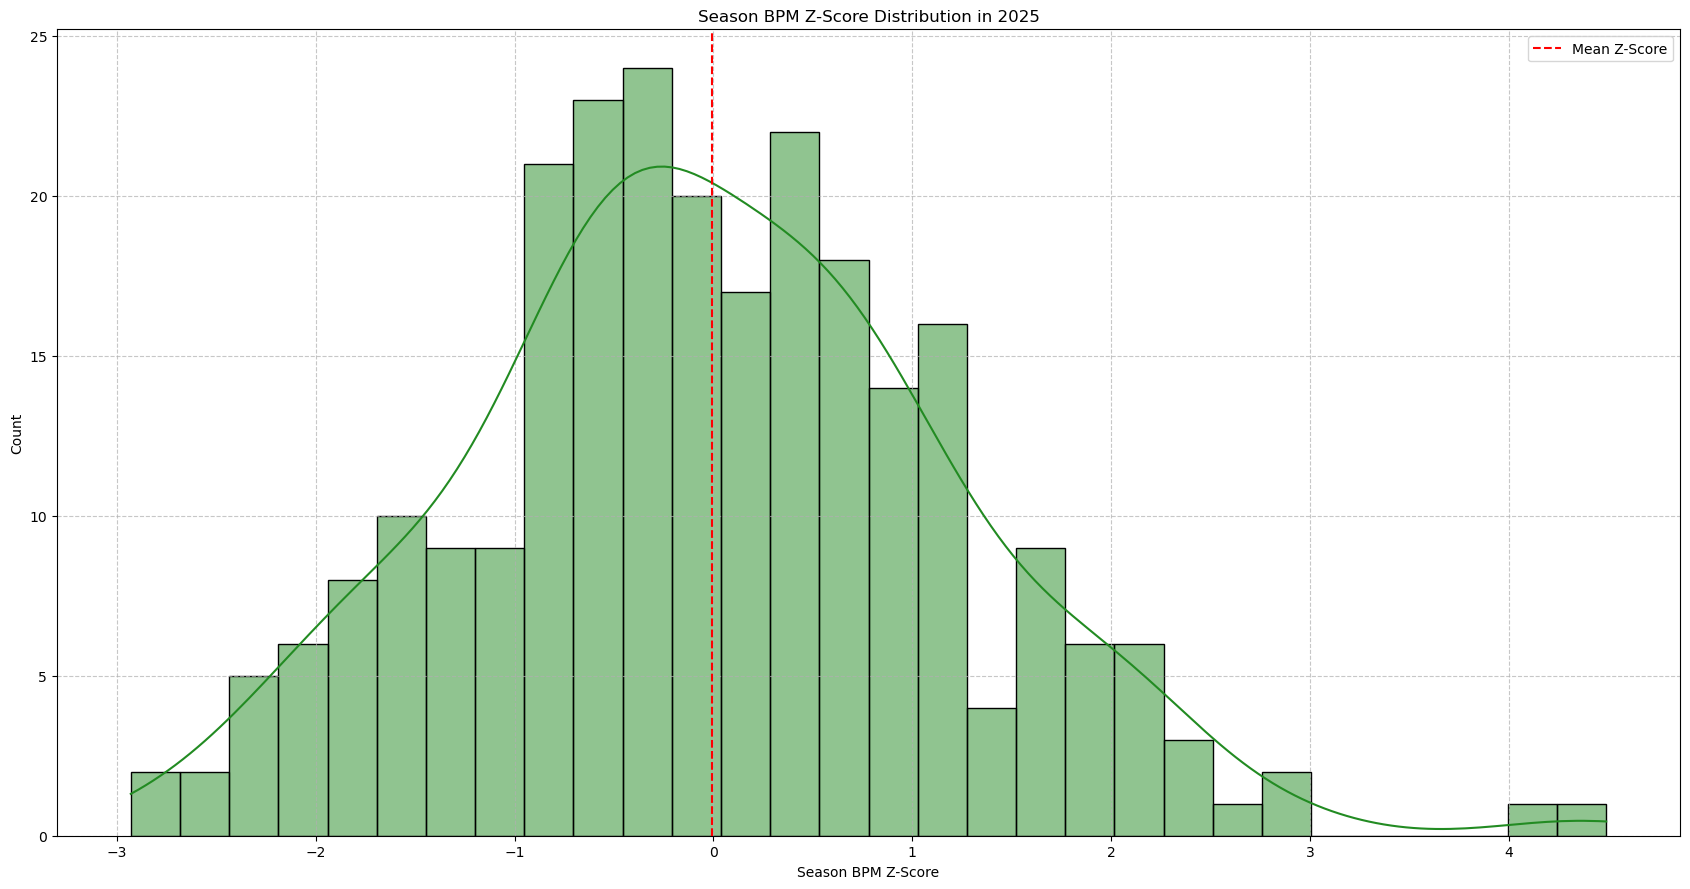

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = (
    df.loc[df.groupby(["athlete_id", "season"])["minutes"].transform("sum") >= 1000]
    .query("season == 2025")
    .drop_duplicates(subset=["athlete_id", "season"])
    .copy()
)

plt.figure(figsize=(17, 9))

sns.histplot(
    data=plot_df,
    x="season_bpm_zscore",
    bins=30,
    kde=True,
    stat="count",
    fill=True,
    alpha=0.5,
    color="forestgreen",
)
plt.title("Season BPM Z-Score Distribution in 2025")
plt.xlabel("Season BPM Z-Score")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.axvline(
    plot_df["season_bpm_zscore"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean Z-Score",
)
plt.legend()
plt.tight_layout()

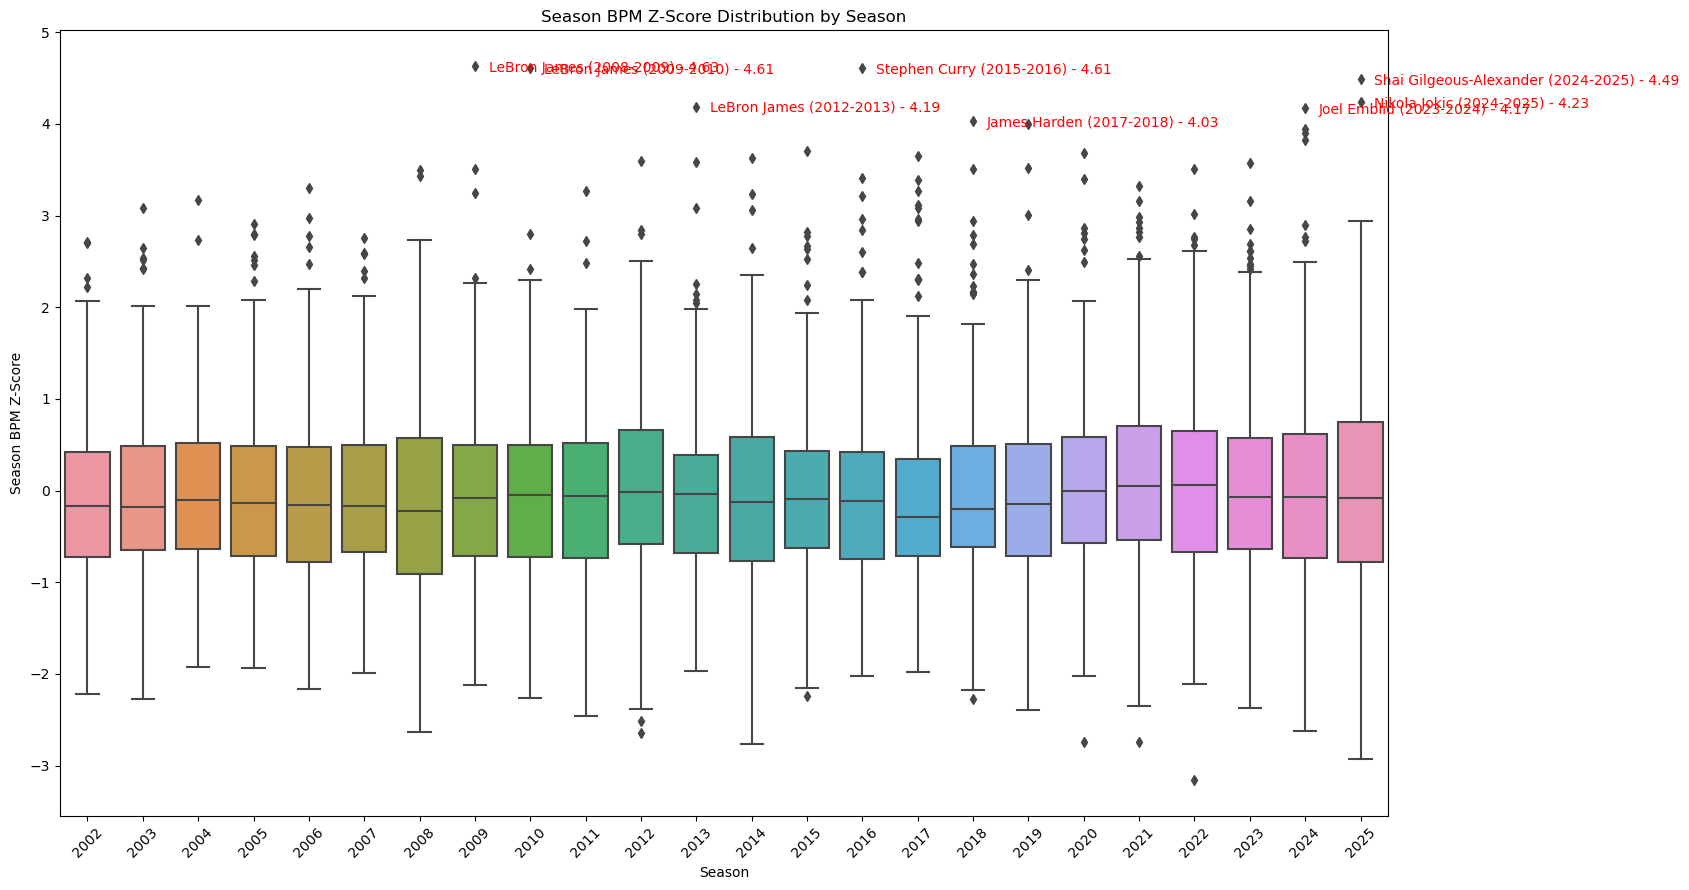

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns


plot_df = df.drop_duplicates(subset=["athlete_id", "season"]).copy()
fig, ax = plt.subplots(figsize=(17, 9))

sns.boxplot(data=plot_df, x="season", y="season_bpm_zscore", ax=ax)

# Add labels for outliers
outliers = plot_df.query("season_bpm_zscore >= 4")

texts = []
for _, row in outliers.iterrows():
    texts.append(
        ax.annotate(
            f"{row['athlete_display_name']} ({row['season'] - 1}-{row['season']}) - {row['season_bpm_zscore']:.2f}",
            xy=(row["season"] - 2002, row["season_bpm_zscore"]),
            xytext=(10, -4),  # Start with no offset
            textcoords="offset points",
            fontsize=10,
            ha="left",
            color="red",
        )
    )

# Automatically adjust text to avoid overlap

plt.title("Season BPM Z-Score Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Season BPM Z-Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("./data/to_display/season_bpm_zscore_boxplot.png", dpi=300)

## Going back to the merged_injuries data


In [26]:
merged_injuries["Acquired"] = (
    merged_injuries["Acquired"].str.split("/").str[0].str.strip()
)
merged_injuries["Relinquished"] = (
    merged_injuries["Relinquished"].str.split("/").str[0].str.strip()
)
merged_injuries = merged_injuries.drop(columns=["Team_y"], errors="ignore").rename(
    columns={"Team_x": "Team"}
)
relinquished = merged_injuries.loc[~merged_injuries["Relinquished"].isna()]
relinquished

,Date,Team,Acquired,Relinquished,Notes,Player,Injury,Injury Category
39,2001-10-29,76ers,NaN,Alvin Jones,placed on IL with right knee tendinitis,NaN,NaN,NaN
40,2001-10-29,76ers,NaN,Eric Snow,placed on IL with broken left thumb,NaN,NaN,NaN
41,2001-10-29,76ers,NaN,Samuel Dalembert,placed on IL with left knee tendinitis,NaN,NaN,NaN
42,2001-10-29,Blazers,NaN,Chris Dudley,placed on IR with right shoulder rotator cuff ...,NaN,NaN,NaN
43,2001-10-29,Blazers,NaN,Mitchell Butler,placed on IL with left knee/quadricaps tendinitis,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
32779,2023-04-09,Grizzlies,NaN,Ja Morant,placed on IL with right hand injury,Ja Morant,right hand injury,Hand
32780,2023-04-09,Grizzlies,NaN,Jaren Jackson Jr.,placed on IL with sore left elbow,Jaren Jackson Jr.,sore left elbow,Other
32785,2023-04-09,Kings,NaN,Davion Mitchell,placed on IL with sore left knee,Davion Mitchell,sore left knee,Knee (Minor)
32786,2023-04-09,Knicks,NaN,Trevor Keels,placed on IL with illness,Trevor Keels,illness,Illness (non-COVID)


In [27]:
relinquished.query("Injury.isna()")

,Date,Team,Acquired,Relinquished,Notes,Player,Injury,Injury Category
39,2001-10-29,76ers,NaN,Alvin Jones,placed on IL with right knee tendinitis,NaN,NaN,NaN
40,2001-10-29,76ers,NaN,Eric Snow,placed on IL with broken left thumb,NaN,NaN,NaN
41,2001-10-29,76ers,NaN,Samuel Dalembert,placed on IL with left knee tendinitis,NaN,NaN,NaN
42,2001-10-29,Blazers,NaN,Chris Dudley,placed on IR with right shoulder rotator cuff ...,NaN,NaN,NaN
43,2001-10-29,Blazers,NaN,Mitchell Butler,placed on IL with left knee/quadricaps tendinitis,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
31866,2023-01-04,Bucks,NaN,Joe Ingles,placed on IL,NaN,NaN,NaN
31902,2023-01-09,Wizards,NaN,Vernon Carey Jr.,placed on IL,NaN,NaN,NaN
31946,2023-01-13,Thunder,NaN,Eugene Omoruyi,placed on IL,NaN,NaN,NaN
32560,2023-03-24,Hornets,NaN,Terry Rozier,right foot injury (DTD),NaN,NaN,NaN


In [28]:
merged_injuries.loc[
    ~(merged_injuries["Relinquished"].isna()) & merged_injuries["Injury"].isna()
]

,Date,Team,Acquired,Relinquished,Notes,Player,Injury,Injury Category
39,2001-10-29,76ers,NaN,Alvin Jones,placed on IL with right knee tendinitis,NaN,NaN,NaN
40,2001-10-29,76ers,NaN,Eric Snow,placed on IL with broken left thumb,NaN,NaN,NaN
41,2001-10-29,76ers,NaN,Samuel Dalembert,placed on IL with left knee tendinitis,NaN,NaN,NaN
42,2001-10-29,Blazers,NaN,Chris Dudley,placed on IR with right shoulder rotator cuff ...,NaN,NaN,NaN
43,2001-10-29,Blazers,NaN,Mitchell Butler,placed on IL with left knee/quadricaps tendinitis,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
31866,2023-01-04,Bucks,NaN,Joe Ingles,placed on IL,NaN,NaN,NaN
31902,2023-01-09,Wizards,NaN,Vernon Carey Jr.,placed on IL,NaN,NaN,NaN
31946,2023-01-13,Thunder,NaN,Eugene Omoruyi,placed on IL,NaN,NaN,NaN
32560,2023-03-24,Hornets,NaN,Terry Rozier,right foot injury (DTD),NaN,NaN,NaN


In [29]:
# injuries.query("'2005-07-01' >= Date >= '2001-07-01'").to_csv(
#     "./data/injuries_recent2.csv", index=False
# )

In [30]:
# gpt_injury_data.query("'2005-07-01' >= Date >= '2001-07-01'").to_csv(
#     "./data/gpt_injuries_recent2.csv", index=False
# )

## Using code rather than AI to create the injury column


In [31]:
injuries = pd.read_csv("./data/injuries.csv")
injuries = (
    injuries.drop(columns=["Unnamed: 0"])
    .query("Date >= '2001-07-01'")
    .reset_index(drop=True)
)
injuries

,Date,Team,Acquired,Relinquished,Notes
0,2001-07-01,76ers,Craig Claxton / Speedy Claxton,NaN,activated from IL
1,2001-07-01,Clippers,Corey Maggette,NaN,activated from IL
2,2001-07-01,Clippers,Earl Boykins,NaN,activated from IL
3,2001-07-01,Grizzlies,Doug West,NaN,activated from IL
4,2001-07-01,Knicks,Luc Longley,NaN,activated from IL
...,...,...,...,...,...
32815,2023-04-16,Clippers,Marcus Morris,NaN,activated from IL
32816,2023-04-16,Grizzlies,Dillon Brooks,NaN,activated from IL
32817,2023-04-16,Grizzlies,Ja Morant,NaN,activated from IL
32818,2023-04-16,Grizzlies,Jaren Jackson Jr.,NaN,activated from IL


In [32]:
import re
import numpy as np

# Load the data

# Filter for injuries (placed on IL) and extract relevant information


def categorize_injury(injury_desc):
    """Categorize injuries into 25 categories based on injury description"""
    if injury_desc is None:
        return np.NaN
    injury_lower = injury_desc.lower()

    # ACL Tears
    if "torn acl" in injury_lower or "acl tear" in injury_lower:
        return "ACL Tear"

    # Achilles injuries
    elif "achilles" in injury_lower:
        if (
            "tear" in injury_lower
            or "rupture" in injury_lower
            or "torn" in injury_lower
        ):
            return "Achilles (Tear)"
        else:
            return "Achilles (Minor)"

    # Ankle injuries
    elif "ankle" in injury_lower:
        return "Ankle"

    # Back injuries
    elif any(term in injury_lower for term in ["back", "spine", "vertebrae", "disc"]):
        return "Back"

    # Calf injuries
    elif "calf" in injury_lower:
        return "Calf"

    # Concussion
    elif "concussion" in injury_lower:
        return "Concussion"

    # Elbow injuries
    elif "elbow" in injury_lower:
        return "Elbow"

    # Eye injuries
    elif "eye" in injury_lower or "orbital" in injury_lower:
        return "Eye"

    # Finger injuries
    elif any(term in injury_lower for term in ["finger", "thumb", "pinky", "pinkie"]):
        return "Finger"

    # Foot injuries
    elif any(term in injury_lower for term in ["foot", "toe", "plantar", "fasciitis"]):
        return "Foot"

    # Groin injuries
    elif "groin" in injury_lower:
        return "Groin"

    # Hamstring injuries
    elif "hamstring" in injury_lower:
        return "Hamstring"

    # Hand injuries
    elif "hand" in injury_lower:
        return "Hand"

    # Head/Neck injuries
    elif any(term in injury_lower for term in ["head", "neck", "cervical"]):
        return "Head/Neck"

    # Hip injuries
    elif "hip" in injury_lower:
        return "Hip"

    # Knee injuries (major)
    elif (
        any(term in injury_lower for term in ["torn", "ruptured", "fractured"])
        and "knee" in injury_lower
    ):
        return "Knee (Major)"

    # Knee injuries (minor)
    elif any(
        term in injury_lower
        for term in ["knee", "patella", "meniscus", "mcl", "kneecap"]
    ):
        return "Knee (Minor)"

    # Leg injuries
    elif "leg" in injury_lower or "shin" in injury_lower:
        return "Leg"

    # Quad/Thigh injuries
    elif any(term in injury_lower for term in ["quadricep", "quad", "thigh"]):
        return "Quad/Thigh"

    # Shoulder injuries
    elif "shoulder" in injury_lower:
        return "Shoulder"

    # Surgery
    elif any(term in injury_lower for term in ["surgery", "surgical", "arthroscopic"]):
        return "Surgery"

    # Wrist injuries
    elif "wrist" in injury_lower:
        return "Wrist"

    # Illness/Other medical
    elif any(
        term in injury_lower
        for term in [
            "illness",
            "infection",
            "virus",
            "flu",
            "kidney",
            "heart",
            "irregular heartbeat",
        ]
    ):
        return "Illness/Medical"

    # General/Other injuries
    elif any(
        term in injury_lower
        for term in ["strain", "sprain", "bruise", "contusion", "inflammation"]
    ):
        return "General Strain/Sprain"

    # Default category
    else:
        return "Other"


# Apply the categorization function to create the new dataset


import re


# ...existing code...


def extract_and_categorize_injury(row):
    # Use pd.isna to check for NaN, not '!='
    if not pd.isna(row["Relinquished"]):
        notes = str(row.get("Notes", "")).lower()
        # Try to extract after "recovering from", else before "(" or use the whole notes
        injury_desc = None
        if "recovering from" in notes:
            # e.g. "placed on il recovering from surgery on right foot (DTD)"
            match = re.search(r"recovering from ([^()]+)", notes)
            if match:
                injury_desc = match.group(1).strip()
        elif "(" in notes:
            injury_desc = notes.split("(")[0].strip()
        else:
            injury_desc = notes.strip()
        if injury_desc:
            return categorize_injury(injury_desc)
        return None
    return np.NaN  # If Relinquished is NaN, return NaN


# ...existing code...


# Apply to all rows
injuries["Injury_Category"] = injuries.apply(extract_and_categorize_injury, axis=1)  # type: ignore

# Add new column to original DataFrame
injuries["Injury_Category"] = injuries.apply(
    extract_and_categorize_injury, axis=1  # type: ignore
)
injuries = injuries.reset_index(drop=True)
injuries

,Date,Team,Acquired,Relinquished,Notes,Injury_Category
0,2001-07-01,76ers,Craig Claxton / Speedy Claxton,NaN,activated from IL,NaN
1,2001-07-01,Clippers,Corey Maggette,NaN,activated from IL,NaN
2,2001-07-01,Clippers,Earl Boykins,NaN,activated from IL,NaN
3,2001-07-01,Grizzlies,Doug West,NaN,activated from IL,NaN
4,2001-07-01,Knicks,Luc Longley,NaN,activated from IL,NaN
...,...,...,...,...,...,...
32815,2023-04-16,Clippers,Marcus Morris,NaN,activated from IL,NaN
32816,2023-04-16,Grizzlies,Dillon Brooks,NaN,activated from IL,NaN
32817,2023-04-16,Grizzlies,Ja Morant,NaN,activated from IL,NaN
32818,2023-04-16,Grizzlies,Jaren Jackson Jr.,NaN,activated from IL,NaN


In [33]:
injuries["Acquired"] = injuries["Acquired"].str.split("/").str[0].str.strip()
injuries["Relinquished"] = injuries["Relinquished"].str.split("/").str[0].str.strip()
injuries = injuries.drop(columns=["Team_y"], errors="ignore").rename(
    columns={"Team_x": "Team"}
)
relinquished = injuries.loc[~injuries["Relinquished"].isna()]
relinquished

,Date,Team,Acquired,Relinquished,Notes,Injury_Category
39,2001-10-29,76ers,NaN,Alvin Jones,placed on IL with right knee tendinitis,Knee (Minor)
40,2001-10-29,76ers,NaN,Eric Snow,placed on IL with broken left thumb,Finger
41,2001-10-29,76ers,NaN,Samuel Dalembert,placed on IL with left knee tendinitis,Knee (Minor)
42,2001-10-29,Blazers,NaN,Chris Dudley,placed on IR with right shoulder rotator cuff ...,Shoulder
43,2001-10-29,Blazers,NaN,Mitchell Butler,placed on IL with left knee/quadricaps tendinitis,Knee (Minor)
...,...,...,...,...,...,...
32777,2023-04-09,Grizzlies,NaN,Ja Morant,placed on IL with right hand injury,Hand
32778,2023-04-09,Grizzlies,NaN,Jaren Jackson Jr.,placed on IL with sore left elbow,Elbow
32783,2023-04-09,Kings,NaN,Davion Mitchell,placed on IL with sore left knee,Knee (Minor)
32784,2023-04-09,Knicks,NaN,Trevor Keels,placed on IL with illness,Illness/Medical


### Define other based on days?


In [34]:
relinquished["Injury_Category"].value_counts()

Injury_Category
Other              7328
Knee (Minor)       1954
Ankle              1689
Back                878
Illness/Medical     823
                   ... 
Knee (Major)         92
ACL Tear             79
Surgery              57
Eye                  44
Achilles (Tear)      37
Name: count, Length: 26, dtype: int64

In [35]:
relinquished.loc[relinquished["Injury_Category"] == "Illness/Medical"]

,Date,Team,Acquired,Relinquished,Notes,Injury_Category
216,2001-12-01,Pacers,NaN,Carlos Rogers,placed on IL with upper respiratory infection,Illness/Medical
698,2002-10-28,Cavaliers,NaN,Dajuan Wagner,placed on IL with bladder infection,Illness/Medical
707,2002-10-28,Heat,NaN,Alonzo Mourning,placed on IL with kidney disorder,Illness/Medical
903,2003-01-06,Pistons,NaN,Zeljko Rebraca,placed on IL with irregular heartbeat,Illness/Medical
1029,2003-02-25,Cavaliers,NaN,Vernell Coles,placed on IL with flu,Illness/Medical
...,...,...,...,...,...,...
32693,2023-04-04,Hawks,NaN,Trae Young,placed on IL with illness,Illness/Medical
32702,2023-04-04,Wizards,NaN,Delon Wright,placed on IL with illness,Illness/Medical
32731,2023-04-06,Nuggets,NaN,Kentavious Caldwell-Pope,placed on IL with illness,Illness/Medical
32757,2023-04-07,Warriors,NaN,Ty Jerome,placed on IL with illness,Illness/Medical


In [36]:
injuries.to_csv("./data/injuries_code_classified.csv", index=False)

In [37]:
(
    df.loc[df.groupby(["athlete_id", "season"])["minutes"].transform("sum") >= 1000]
    .drop_duplicates(subset=["athlete_id", "season"])
    .copy()
    .query("athlete_display_name == 'Michael Jordan'")
)

,game_id,season,season_type,game_date,game_date_time,athlete_id,athlete_display_name,team_id,team_name,team_location,team_short_display_name,minutes,fgm,fga,3pm,3pa,ftm,fta,orb,drb,rebounds,assists,steals,blocks,turnovers,fouls,plus_minus,points,starter,ejected,did_not_play,active,athlete_jersey,athlete_short_name,athlete_headshot_href,athlete_position_name,athlete_position_abbreviation,team_display_name,team_uid,team_slug,team_logo,team_abbreviation,team_color,team_alternate_color,home_away,team_winner,team_score,opponent_team_id,opponent_team_name,opponent_team_location,opponent_team_display_name,opponent_team_abbreviation,opponent_team_logo,opponent_team_color,opponent_team_alternate_color,opponent_team_score,reason,season_team,season_type_team,game_date_team,game_date_time_team,team_uid_team,team_slug_team,team_location_team,team_name_team,team_abbreviation_team,team_display_name_team,team_short_display_name_team,team_color_team,team_alternate_color_team,team_logo_team,team_home_away,points_team,team_winner_team,assists_team,blocks_team,defensive_rebounds_team,fast_break_points,field_goal_pct,field_goals_made_team,fga_team,flagrant_fouls,fouls_team,free_throw_pct,free_throws_made_team,fta_team,orb_team,points_in_paint,steals_team,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made_team,three_point_field_goals_attempted_team,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,tov_team,opponent_team_id_team,opponent_team_uid,opponent_team_slug,opponent_team_location_team,opponent_team_name_team,opponent_team_abbreviation_team,opponent_team_display_name_team,opponent_team_short_display_name,opponent_team_color_team,opponent_team_alternate_color_team,opponent_team_logo_team,opponent_team_score_team,largest_lead,possessions_team,minutes_team,possessions,points_per_100_possessions,3pm_per_100_possessions,assists_per_100_possessions,turnovers_per_100_possessions,orb_per_100_possessions,drb_per_100_possessions,steals_per_100_possessions,blocks_per_100_possessions,fouls_per_100_possessions,fga_per_100_possessions,fta_per_100_possessions,raw_bpm,minutes_z_score_player_season,season_avg_minutes,team_adjustment,adjusted_team_efficiency,adjusted_bpm,raw_bpm*mins,bpm*mins,cumulative_raw_bpm_contribution,cumulative_bpm_contribution,average_bpm_contribution,avg*mins,cumulative_average_bpm_contribution,final_average_bpm_contribution,cumulative_average_z_score_player_season,calculated_position,bpm,season_bpm,season_bpm_zscore
117,211030018,2002,2,2001-10-30,2001-10-31T00:30:00Z,1035.0,Michael Jordan,27,Wizards,Washington,Wizards,37.0,7.0,21.0,0.0,3.0,5.0,6.0,3.0,2.0,5.0,6.0,4.0,0.0,3.0,3.0,0,19.0,True,False,False,False,23.0,M. Jordan,NaN,Guard,G,Washington Wizards,s:40~l:46~t:27,washington-wizards,https://a.espncdn.com/i/teamlogos/nba/500/wsh.png,WSH,0E3764,e31837,away,False,91,18,Knicks,New York,New York Knicks,NY,https://a.espncdn.com/i/teamlogos/nba/500/ny.png,225EA8,f58426,93,NaN,2002.0,2.0,2001-10-30,2001-10-31T00:30:00Z,s:40~l:46~t:27,washington-wizards,Washington,Wizards,WSH,Washington Wizards,Wizards,0E3764,e31837,https://a.espncdn.com/i/teamlogos/nba/500/wsh.png,away,91.0,False,23.0,4.0,30.0,10.0,43.9,36.0,82.0,0.0,27.0,72.2,13.0,18.0,9.0,-1.0,11.0,15.0,0.0,46.2,6.0,13.0,46.0,0.0,30.0,17.0,15.0,18.0,s:40~l:46~t:18,new-york-knicks,New York,Knicks,NY,New York Knicks,Knicks,225EA8,f58426,https://a.espncdn.com/i/teamlogos/nba/500/ny.png,93.0,NaN,95.92,48.0,74,25.68,0.0,8.11,4.05,4.05,2.70,5.41,0.0,4.05,28.38,8.11,10.27461,0.342186,34.883333,-8.436570,-0.319902,1.838040,380.16057,35.114294,10.27461,1.838040,6.056325,224.084027,6.056325,6.999424,0.560326,2.181291,0.949035,1.636031,0.486667
19612,221030028,2003,2,2002-10-30,2002-10-31T00:00:00Z,1035.0,Michael Jordan,27,Wizards,Washington,Wizards,25.0,4.0,14.0,0.0,0.0,0.0,2.0,0.0,3.0,3.0,1.0,3.0,0.0,2.0,3.0,0,8.0,False,False,False,True,23.0,M. Jordan,NaN,Guard,G,Washington Wizards,s:40~l:46~t:27,washington-wizards,https://a.espncdn.com/i/

In [38]:
injuries = pd.read_csv("./data/injuries_code_classified.csv")
injuries

,Date,Team,Acquired,Relinquished,Notes,Injury_Category
0,2001-07-01,76ers,Craig Claxton,NaN,activated from IL,NaN
1,2001-07-01,Clippers,Corey Maggette,NaN,activated from IL,NaN
2,2001-07-01,Clippers,Earl Boykins,NaN,activated from IL,NaN
3,2001-07-01,Grizzlies,Doug West,NaN,activated from IL,NaN
4,2001-07-01,Knicks,Luc Longley,NaN,activated from IL,NaN
...,...,...,...,...,...,...
32815,2023-04-16,Clippers,Marcus Morris,NaN,activated from IL,NaN
32816,2023-04-16,Grizzlies,Dillon Brooks,NaN,activated from IL,NaN
32817,2023-04-16,Grizzlies,Ja Morant,NaN,activated from IL,NaN
32818,2023-04-16,Grizzlies,Jaren Jackson Jr.,NaN,activated from IL,NaN


In [39]:
injuries

,Date,Team,Acquired,Relinquished,Notes,Injury_Category
0,2001-07-01,76ers,Craig Claxton,NaN,activated from IL,NaN
1,2001-07-01,Clippers,Corey Maggette,NaN,activated from IL,NaN
2,2001-07-01,Clippers,Earl Boykins,NaN,activated from IL,NaN
3,2001-07-01,Grizzlies,Doug West,NaN,activated from IL,NaN
4,2001-07-01,Knicks,Luc Longley,NaN,activated from IL,NaN
...,...,...,...,...,...,...
32815,2023-04-16,Clippers,Marcus Morris,NaN,activated from IL,NaN
32816,2023-04-16,Grizzlies,Dillon Brooks,NaN,activated from IL,NaN
32817,2023-04-16,Grizzlies,Ja Morant,NaN,activated from IL,NaN
32818,2023-04-16,Grizzlies,Jaren Jackson Jr.,NaN,activated from IL,NaN


In [40]:
pd.set_option("display.max_columns", 1000)
df.query("athlete_display_name == 'Jonathan Kuminga' and season == 2025").head(10)[
    [
        "minutes",
        "points",
        "assists",
        "rebounds",
        "steals",
        "blocks",
        "turnovers",
        "fouls",
        "fgm",
        "fga",
        "adjusted_bpm",
    ]
]

,minutes,points,assists,rebounds,steals,blocks,turnovers,fouls,fgm,fga,adjusted_bpm
472366,20.0,10.0,1.0,4.0,0.0,1.0,4.0,3.0,3.0,9.0,-16.355717
472638,18.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,5.0,-11.293105
472949,22.0,12.0,1.0,5.0,3.0,0.0,1.0,2.0,4.0,10.0,-0.429637
473238,28.0,17.0,3.0,3.0,2.0,1.0,2.0,0.0,6.0,13.0,3.844875
473367,27.0,16.0,2.0,4.0,1.0,0.0,1.0,4.0,6.0,12.0,-2.181690
473727,26.0,23.0,1.0,6.0,0.0,0.0,4.0,0.0,7.0,12.0,1.777780
474085,25.0,15.0,2.0,6.0,1.0,0.0,0.0,0.0,7.0,15.0,-1.860942
474296,18.0,10.0,1.0,4.0,0.0,0.0,1.0,3.0,4.0,10.0,-6.948415
474630,29.0,21.0,5.0,5.0,2.0,1.0,3.0,2.0,7.0,14.0,7.021603
474887,26.0,20.0,1.0,5.0,0.0,1.0,2.0,2.0,8.0,11.0,5.486940


In [41]:
# df["raw_bpm*mins"] = df["raw_bpm"] * df["minutes"]
# df["adjusted_bpm*mins"] = df["adjusted_bpm"] * df["minutes"]
# df["bpm*mins"] = df["bpm"] * df["minutes"]

# # ? Is it correct to query by over 12 minutes here?
# df = df.query("minutes >= 12").reset_index(drop=True)

# # standardized by minutes
# df["cumulative_raw_bpm_contribution"] = (
#     df.groupby(["season", "athlete_id"])["raw_bpm*mins"]
#     .cumsum()
#     .divide(df.groupby(["season", "athlete_id"])["minutes"].cumsum())
# )
# df["cumulative_bpm_contribution"] = (
#     df.groupby(["season", "athlete_id"])["bpm*mins"]
#     .cumsum()
#     .divide(df.groupby(["season", "athlete_id"])["minutes"].cumsum())
# )

# df["average_bpm_contribution"] = (df["raw_bpm"] + df["adjusted_bpm"]) / 2
# df["avg*mins"] = df["average_bpm_contribution"] * df["minutes"]
# df["cumulative_average_bpm_contribution"] = (
#     df.groupby(["season", "athlete_id"])["avg*mins"]
#     .cumsum()
#     .divide(df.groupby(["season", "athlete_id"])["minutes"].cumsum())
# )

# df["final_average_bpm_contribution"] = (
#     df.groupby(["season", "athlete_id"])["avg*mins"]
#     .transform("sum")
#     .divide(df.groupby(["season", "athlete_id"])["minutes"].transform("sum"))
# )

# df[
#     [
#         "athlete_display_name",
#         "game_date",
#         "minutes",
#         "adjusted_bpm",
#         "cumulative_bpm_contribution",
#     ]
# ]

In [42]:
df["cumulative_adjusted_bpm_zscore"] = (
    df.groupby(["athlete_id", "season"])["adjusted_bpm"]
    .transform(lambda x: (x - x.mean()) / x.std())
    .fillna(0)
)

In [43]:
df

,game_id,season,season_type,game_date,game_date_time,athlete_id,athlete_display_name,team_id,team_name,team_location,team_short_display_name,minutes,fgm,fga,3pm,3pa,ftm,fta,orb,drb,rebounds,assists,steals,blocks,turnovers,fouls,plus_minus,points,starter,ejected,did_not_play,active,athlete_jersey,athlete_short_name,athlete_headshot_href,athlete_position_name,athlete_position_abbreviation,team_display_name,team_uid,team_slug,team_logo,team_abbreviation,team_color,team_alternate_color,home_away,team_winner,team_score,opponent_team_id,opponent_team_name,opponent_team_location,opponent_team_display_name,opponent_team_abbreviation,opponent_team_logo,opponent_team_color,opponent_team_alternate_color,opponent_team_score,reason,season_team,season_type_team,game_date_team,game_date_time_team,team_uid_team,team_slug_team,team_location_team,team_name_team,team_abbreviation_team,team_display_name_team,team_short_display_name_team,team_color_team,team_alternate_color_team,team_logo_team,team_home_away,points_team,team_winner_team,assists_team,blocks_team,defensive_rebounds_team,fast_break_points,field_goal_pct,field_goals_made_team,fga_team,flagrant_fouls,fouls_team,free_throw_pct,free_throws_made_team,fta_team,orb_team,points_in_paint,steals_team,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made_team,three_point_field_goals_attempted_team,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,tov_team,opponent_team_id_team,opponent_team_uid,opponent_team_slug,opponent_team_location_team,opponent_team_name_team,opponent_team_abbreviation_team,opponent_team_display_name_team,opponent_team_short_display_name,opponent_team_color_team,opponent_team_alternate_color_team,opponent_team_logo_team,opponent_team_score_team,largest_lead,possessions_team,minutes_team,possessions,points_per_100_possessions,3pm_per_100_possessions,assists_per_100_possessions,turnovers_per_100_possessions,orb_per_100_possessions,drb_per_100_possessions,steals_per_100_possessions,blocks_per_100_possessions,fouls_per_100_possessions,fga_per_100_possessions,fta_per_100_possessions,raw_bpm,minutes_z_score_player_season,season_avg_minutes,team_adjustment,adjusted_team_efficiency,adjusted_bpm,raw_bpm*mins,bpm*mins,cumulative_raw_bpm_contribution,cumulative_bpm_contribution,average_bpm_contribution,avg*mins,cumulative_average_bpm_contribution,final_average_bpm_contribution,cumulative_average_z_score_player_season,calculated_position,bpm,season_bpm,season_bpm_zscore,cumulative_adjusted_bpm_zscore
0,211030019,2002,2,2001-10-30,2001-10-31T00:30:00Z,353.0,Troy Hudson,19,Magic,Orlando,Magic,19.0,6.0,11.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,0.0,3.0,3.0,0,12.0,False,False,False,False,6.0,T. Hudson,NaN,Point Guard,PG,Orlando Magic,s:40~l:46~t:19,orlando-magic,https://a.espncdn.com/i/teamlogos/nba/500/orl.png,ORL,0860A8,c4ced3,home,True,114,28,Raptors,Toronto,Toronto Raptors,TOR,https://a.espncdn.com/i/teamlogos/nba/500/tor.png,CE0F41,061922,85,NaN,2002.0,2.0,2001-10-30,2001-10-31T00:30:00Z,s:40~l:46~t:19,orlando-magic,Orlando,Magic,ORL,Orlando Magic,Magic,0860A8,c4ced3,https://a.espncdn.com/i/teamlogos/nba/500/orl.png,home,114.0,True,23.0,7.0,27.0,9.0,61.1,44.0,72.0,0.0,31.0,71.0,22.0,31.0,10.0,-1.0,12.0,19.0,1.0,50.0,4.0,8.0,47.0,1.0,38.0,23.0,19.0,28.0,s:40~l:46~t:28,toronto-raptors,Toronto,Raptors,TOR,Toronto Raptors,Raptors,CE0F41,061922,https://a.espncdn.com/i/teamlogos/nba/500/tor.png,85.0,NaN,94.64,48.0,37,32.43,0.00,5.41,8.11,0.00,5.41,0.00,0.00,8.11,29.73,0.00,0.619950,-0.447828,23.542169,-6.820928,2.758450,-6.200978,11.779050,91.184069,0.619950,-6.200978,-2.790514,-53.019766,-2.790514,3.514053,-1.761281,1.860991,4.799162,-1.186313,-0.576446,-0.663464
1,211030023,2002,2,2001-10-30,2001-10-31T00:00:00Z,376.0,Bobby Jackson,23,Kings,Sacramento,Kings,19.0,3.0,4.0,1.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,2.0,5.0,0,7.0,False,False,False,False,24.0,B. Jackson,NaN,Point Guard,PG,Sacramento Kings,s:40~l:46~t:23,sacramento-kings,https://a

In [44]:
df.query("athlete_display_name == 'Alvin Jones'").head(10)

,game_id,season,season_type,game_date,game_date_time,athlete_id,athlete_display_name,team_id,team_name,team_location,team_short_display_name,minutes,fgm,fga,3pm,3pa,ftm,fta,orb,drb,rebounds,assists,steals,blocks,turnovers,fouls,plus_minus,points,starter,ejected,did_not_play,active,athlete_jersey,athlete_short_name,athlete_headshot_href,athlete_position_name,athlete_position_abbreviation,team_display_name,team_uid,team_slug,team_logo,team_abbreviation,team_color,team_alternate_color,home_away,team_winner,team_score,opponent_team_id,opponent_team_name,opponent_team_location,opponent_team_display_name,opponent_team_abbreviation,opponent_team_logo,opponent_team_color,opponent_team_alternate_color,opponent_team_score,reason,season_team,season_type_team,game_date_team,game_date_time_team,team_uid_team,team_slug_team,team_location_team,team_name_team,team_abbreviation_team,team_display_name_team,team_short_display_name_team,team_color_team,team_alternate_color_team,team_logo_team,team_home_away,points_team,team_winner_team,assists_team,blocks_team,defensive_rebounds_team,fast_break_points,field_goal_pct,field_goals_made_team,fga_team,flagrant_fouls,fouls_team,free_throw_pct,free_throws_made_team,fta_team,orb_team,points_in_paint,steals_team,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made_team,three_point_field_goals_attempted_team,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,tov_team,opponent_team_id_team,opponent_team_uid,opponent_team_slug,opponent_team_location_team,opponent_team_name_team,opponent_team_abbreviation_team,opponent_team_display_name_team,opponent_team_short_display_name,opponent_team_color_team,opponent_team_alternate_color_team,opponent_team_logo_team,opponent_team_score_team,largest_lead,possessions_team,minutes_team,possessions,points_per_100_possessions,3pm_per_100_possessions,assists_per_100_possessions,turnovers_per_100_possessions,orb_per_100_possessions,drb_per_100_possessions,steals_per_100_possessions,blocks_per_100_possessions,fouls_per_100_possessions,fga_per_100_possessions,fta_per_100_possessions,raw_bpm,minutes_z_score_player_season,season_avg_minutes,team_adjustment,adjusted_team_efficiency,adjusted_bpm,raw_bpm*mins,bpm*mins,cumulative_raw_bpm_contribution,cumulative_bpm_contribution,average_bpm_contribution,avg*mins,cumulative_average_bpm_contribution,final_average_bpm_contribution,cumulative_average_z_score_player_season,calculated_position,bpm,season_bpm,season_bpm_zscore,cumulative_adjusted_bpm_zscore
15879,220320020,2002,2,2002-03-20,2002-03-21T00:00:00Z,1009.0,Alvin Jones,20,76ers,Philadelphia,76ers,13.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,4.0,1.0,1.0,1.0,1.0,4.0,0,2.0,False,False,False,False,42.0,A. Jones,NaN,Center,C,Philadelphia 76ers,s:40~l:46~t:20,philadelphia-76ers,https://a.espncdn.com/i/teamlogos/nba/500/phi.png,PHI,000000,f1f2f3,home,False,77,14,Heat,Miami,Miami Heat,MIA,https://a.espncdn.com/i/teamlogos/nba/500/mia.png,000000,000000,82,NaN,2002.0,2.0,2002-03-20,2002-03-21T00:00:00Z,s:40~l:46~t:20,philadelphia-76ers,Philadelphia,76ers,PHI,Philadelphia 76ers,76ers,000000,f1f2f3,https://a.espncdn.com/i/teamlogos/nba/500/phi.png,home,77.0,False,11.0,4.0,31.0,2.0,37.0,27.0,73.0,0.0,20.0,84.0,21.0,25.0,13.0,-1.0,7.0,12.0,1.0,16.7,2.0,12.0,46.0,1.0,24.0,12.0,12.0,14.0,s:40~l:46~t:14,miami-heat,Miami,Heat,MIA,Miami Heat,Heat,000000,000000,https://a.espncdn.com/i/teamlogos/nba/500/mia.png,82.0,NaN,83.00,48.0,22,9.09,0.0,4.55,4.55,4.55,13.64,4.55,4.55,18.18,4.55,0.00,11.76628,1.834504,12.571429,-10.245324,-2.378836,1.520956,152.96164,-25.071976,11.766280,1.520956,6.643618,86.367035,6.643618,-0.434979,0.714444,3.03944,-1.928614,-3.206714,NaN,0.922658
16847,220328004,2002,2,2002-03-28,2002-03-29T00:30:00Z,1009.0,Alvin Jones,20,76ers,Philadelphia,76ers,15.0,1.0,2.0,0.0,0.0,2.0,4.0,1.0,3.0,4.0,0.0,1.0,2.0,1.0,2.0,0,4.0,False,False,False,True,42.0,A. Jones,NaN,Center,C,Philadelphia 76ers,s:40~l:46~t:20,philadelphia-76ers,https://a.espncdn.co

In [45]:
acquired = injuries.loc[~injuries["Acquired"].isna()]
acquired.query("Acquired == 'Alvin Jones'")

,Date,Team,Acquired,Relinquished,Notes,Injury_Category
120,2001-11-09,76ers,Alvin Jones,NaN,activated from IL,NaN
508,2002-03-01,76ers,Alvin Jones,NaN,activated from IL,NaN


In [46]:
relinquished

,Date,Team,Acquired,Relinquished,Notes,Injury_Category
39,2001-10-29,76ers,NaN,Alvin Jones,placed on IL with right knee tendinitis,Knee (Minor)
40,2001-10-29,76ers,NaN,Eric Snow,placed on IL with broken left thumb,Finger
41,2001-10-29,76ers,NaN,Samuel Dalembert,placed on IL with left knee tendinitis,Knee (Minor)
42,2001-10-29,Blazers,NaN,Chris Dudley,placed on IR with right shoulder rotator cuff ...,Shoulder
43,2001-10-29,Blazers,NaN,Mitchell Butler,placed on IL with left knee/quadricaps tendinitis,Knee (Minor)
...,...,...,...,...,...,...
32777,2023-04-09,Grizzlies,NaN,Ja Morant,placed on IL with right hand injury,Hand
32778,2023-04-09,Grizzlies,NaN,Jaren Jackson Jr.,placed on IL with sore left elbow,Elbow
32783,2023-04-09,Kings,NaN,Davion Mitchell,placed on IL with sore left knee,Knee (Minor)
32784,2023-04-09,Knicks,NaN,Trevor Keels,placed on IL with illness,Illness/Medical


In [47]:
df.query("athlete_display_name == 'Klay Thompson' and season == 2015").tail(16)

,game_id,season,season_type,game_date,game_date_time,athlete_id,athlete_display_name,team_id,team_name,team_location,team_short_display_name,minutes,fgm,fga,3pm,3pa,ftm,fta,orb,drb,rebounds,assists,steals,blocks,turnovers,fouls,plus_minus,points,starter,ejected,did_not_play,active,athlete_jersey,athlete_short_name,athlete_headshot_href,athlete_position_name,athlete_position_abbreviation,team_display_name,team_uid,team_slug,team_logo,team_abbreviation,team_color,team_alternate_color,home_away,team_winner,team_score,opponent_team_id,opponent_team_name,opponent_team_location,opponent_team_display_name,opponent_team_abbreviation,opponent_team_logo,opponent_team_color,opponent_team_alternate_color,opponent_team_score,reason,season_team,season_type_team,game_date_team,game_date_time_team,team_uid_team,team_slug_team,team_location_team,team_name_team,team_abbreviation_team,team_display_name_team,team_short_display_name_team,team_color_team,team_alternate_color_team,team_logo_team,team_home_away,points_team,team_winner_team,assists_team,blocks_team,defensive_rebounds_team,fast_break_points,field_goal_pct,field_goals_made_team,fga_team,flagrant_fouls,fouls_team,free_throw_pct,free_throws_made_team,fta_team,orb_team,points_in_paint,steals_team,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made_team,three_point_field_goals_attempted_team,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,tov_team,opponent_team_id_team,opponent_team_uid,opponent_team_slug,opponent_team_location_team,opponent_team_name_team,opponent_team_abbreviation_team,opponent_team_display_name_team,opponent_team_short_display_name,opponent_team_color_team,opponent_team_alternate_color_team,opponent_team_logo_team,opponent_team_score_team,largest_lead,possessions_team,minutes_team,possessions,points_per_100_possessions,3pm_per_100_possessions,assists_per_100_possessions,turnovers_per_100_possessions,orb_per_100_possessions,drb_per_100_possessions,steals_per_100_possessions,blocks_per_100_possessions,fouls_per_100_possessions,fga_per_100_possessions,fta_per_100_possessions,raw_bpm,minutes_z_score_player_season,season_avg_minutes,team_adjustment,adjusted_team_efficiency,adjusted_bpm,raw_bpm*mins,bpm*mins,cumulative_raw_bpm_contribution,cumulative_bpm_contribution,average_bpm_contribution,avg*mins,cumulative_average_bpm_contribution,final_average_bpm_contribution,cumulative_average_z_score_player_season,calculated_position,bpm,season_bpm,season_bpm_zscore,cumulative_adjusted_bpm_zscore
277461,400579252,2015,2,2015-03-11,2015-03-12T02:30:00Z,6475.0,Klay Thompson,9,Warriors,Golden State,Warriors,35.0,11.0,19.0,3.0,6.0,2.0,2.0,0.0,2.0,2.0,3.0,1.0,1.0,2.0,1.0,11,27.0,True,False,False,False,11.0,K. Thompson,https://a.espncdn.com/i/headshots/nba/players/...,Shooting Guard,SG,Golden State Warriors,s:40~l:46~t:9,golden-state-warriors,https://a.espncdn.com/i/teamlogos/nba/500/gs.png,GS,00275D,fdb927,home,True,105,8,Pistons,Detroit,Detroit Pistons,DET,https://a.espncdn.com/i/teamlogos/nba/500/det.png,FA002C,006bb6,98,COACH'S DECISION,2015.0,2.0,2015-03-11,2015-03-12T02:30:00Z,s:40~l:46~t:9,golden-state-warriors,Golden State,Warriors,GS,Golden State Warriors,Warriors,00275D,fdb927,https://a.espncdn.com/i/teamlogos/nba/500/gs.png,home,105.0,True,29.0,6.0,32.0,14.0,52.4,44.0,84.0,0.0,11.0,76.9,10.0,13.0,10.0,58.0,5.0,0.0,0.0,35.0,7.0,20.0,45.0,0.0,17.0,16.0,17.0,8.0,s:40~l:46~t:8,detroit-pistons,Detroit,Pistons,DET,Detroit Pistons,Pistons,FA002C,006bb6,https://a.espncdn.com/i/teamlogos/nba/500/det.png,98.0,NaN,96.72,48.0,71,38.03,4.23,4.23,2.82,0.00,2.82,1.41,1.41,1.41,26.76,2.82,18.860413,0.391239,32.727273,-5.737473,6.786939,13.122940,660.114438,324.750021,14.340970,8.682700,15.991676,559.708668,11.511835,10.673974,1.730606,2.349774,9.278572,5.866904,2.08034,0.378337
277877,400579273,2015,2,2015-03-14,2015-03-15T02:30:00Z,6475.0,Klay Thompson,9,Warriors,Golden State,Warriors,26.0,9.0,17.0,6.0,10.0,3.0,3.0,0.0,2.0,2.0,2.0,0.0,0.0,

In [48]:
klay = injuries.query(
    "Relinquished == 'Klay Thompson' or Acquired == 'Klay Thompson'"
).reset_index(drop=True)
klay

,Date,Team,Acquired,Relinquished,Notes,Injury_Category
0,2015-03-18,Warriors,NaN,Klay Thompson,placed on IL with sprained right ankle,Ankle
1,2015-03-23,Warriors,Klay Thompson,NaN,activated from IL,NaN
2,2017-01-10,Warriors,NaN,Klay Thompson,placed on IL for rest,Other
3,2017-01-12,Warriors,Klay Thompson,NaN,activated from IL,NaN
4,2018-01-10,Warriors,NaN,Klay Thompson,placed on IL,Other
...,...,...,...,...,...,...
36,2022-12-16,Warriors,Klay Thompson,NaN,activated from IL,NaN
37,2022-12-28,Warriors,NaN,Klay Thompson,placed on IL with right Achilles injury,Achilles (Minor)
38,2022-12-30,Warriors,Klay Thompson,NaN,activated from IL,NaN
39,2023-04-04,Warriors,NaN,Klay Thompson,placed on IL with sore back,Back


In [49]:
team = pd.read_csv("./data/team_box_standard.csv")
team

,game_id,season,season_type,game_date,game_date_time,team_id,team_uid,team_slug,team_location,team_name,team_abbreviation,team_display_name,team_short_display_name,team_color,team_alternate_color,team_logo,team_home_away,team_score,team_winner,assists,blocks,defensive_rebounds,fast_break_points,field_goal_pct,field_goals_made,field_goals_attempted,flagrant_fouls,fouls,free_throw_pct,free_throws_made,free_throws_attempted,offensive_rebounds,points_in_paint,steals,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made,three_point_field_goals_attempted,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,turnovers,opponent_team_id,opponent_team_uid,opponent_team_slug,opponent_team_location,opponent_team_name,opponent_team_abbreviation,opponent_team_display_name,opponent_team_short_display_name,opponent_team_color,opponent_team_alternate_color,opponent_team_logo,opponent_team_score,largest_lead
0,220612017,2002,3,2002-06-12,2002-06-13T01:00:00Z,13,s:40~l:46~t:13,los-angeles-lakers,Los Angeles,Lakers,LAL,Los Angeles Lakers,Lakers,542582,552582,https://a.espncdn.com/i/teamlogos/nba/500/lal.png,away,113,True,28,3,32,1,52.1,37,71,0,15,75.7,28,37,7,-1,7,10,1,57.9,11,19,44,1,20,11,10,17,s:40~l:46~t:17,new-jersey-nets,New Jersey,Nets,NJ,New Jersey Nets,Nets,06143F,ffffff,NaN,107,NaN
1,220612017,2002,3,2002-06-12,2002-06-13T01:00:00Z,17,s:40~l:46~t:17,new-jersey-nets,New Jersey,Nets,NJ,New Jersey Nets,Nets,06143F,ffffff,NaN,home,107,False,27,4,27,3,48.9,45,92,0,22,81.3,13,16,14,-1,5,8,2,44.4,4,9,49,2,16,14,8,13,s:40~l:46~t:13,los-angeles-lakers,Los Angeles,Lakers,LAL,Los Angeles Lakers,Lakers,542582,552582,https://a.espncdn.com/i/teamlogos/nba/500/lal.png,113,NaN
2,220609017,2002,3,2002-06-09,2002-06-10T00:30:00Z,13,s:40~l:46~t:13,los-angeles-lakers,Los Angeles,Lakers,LAL,Los Angeles Lakers,Lakers,542582,552582,https://a.espncdn.com/i/teamlogos/nba/500/lal.png,away,106,True,17,10,33,2,54.4,37,68,1,22,68.6,24,35,7,-1,7,19,2,50.0,8,16,51,2,38,15,19,17,s:40~l:46~t:17,new-jersey-nets,New Jersey,Nets,NJ,New Jersey Nets,Nets,06143F,ffffff,NaN,103,NaN
3,220609017,2002,3,2002-06-09,2002-06-10T00:30:00Z,17,s:40~l:46~t:17,new-jersey-nets,New Jersey,Nets,NJ,New Jersey Nets,Nets,06143F,ffffff,NaN,home,103,False,22,5,22,4,51.8,43,83,0,27,73.7,14,19,5,-1,13,13,0,25.0,3,12,36,0,26,25,13,13,s:40~l:46~t:13,los-angeles-lakers,Los Angeles,Lakers,LAL,Los Angeles Lakers,Lakers,542582,552582,https://a.espncdn.com/i/teamlogos/nba/500/lal.png,106,NaN
4,220607013,2002,3,2002-06-07,2002-06-07T22:00:00Z,17,s:40~l:46~t:17,new-jersey-nets,New Jersey,Nets,NJ,New Jersey Nets,Nets,06143F,ffffff,NaN,away,83,False,18,5,23,4,34.9,30,86,0,27,63.0,17,27,20,-1,11,13,0,27.3,6,22,54,0,26,20,13,13,s:40~l:46~t:13,los-angeles-lakers,Los Angeles,Lakers,LAL,Los Angeles Lakers,Lakers,542582,552582,https://a.espncdn.com/i/teamlogos/nba/500/lal.png,106,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61647,401704629,2025,2,2024-10-23,2024-10-23T23:00:00Z,8,s:40~l:46~t:8,detroit-pistons,Detroit,Pistons,DET,Detroit Pistons,Pistons,1d428a,c8102e,https://a.espncdn.com/i/teamlogos/nba/500/det.png,home,109,False,22,2,26,10,43.2,38,88,0,21,85.7,24,28,12,50,6,2,2,27.3,9,33,38,2,14,12,12,11,s:40~l:46~t:11,indiana-pacers,Indiana,Pacers,IND,Indiana Pacers,Pacers,002d62,ffd520,https://a.espncdn.com/i/teamlogos/nba/500/ind.png,115,12.0
61648,401704628,2025,2,2024-10-22,2024-10-23T02:00:00Z,16,s:40~l:46~t:16,minnesota-timberwolves,Minnesota,Timberwolves,MIN,Minnesota Timberwolves,Timberwolves,266092,79bc43,https://a.espncdn.com/i/teamlogos/nba/500/min.png,away,103,False,17,1,35,7,41.2,35,85,0,22,74.1,20,27,12,40,4,1,0,31.7,13,41,47,0,16,19,15,13,s:40~l:46~t:13,los-angeles-lakers,Los Angeles,Lakers,LAL,Los Angeles Lakers,Lakers,552583,fdb927,https://a.espncdn.com/i/team

In [50]:
df.to_csv("./data/bpm_data_to_merge.csv", index=False)

In [ ]:
# team = team.sort_values(by=["season", "game_date"])
# team["dummy"] = 1
# team = team.query("season_type == 2")
# team["game_count"] = team.groupby(["season", "team_id"])["dummy"].cumsum()
# team

,game_id,season,season_type,game_date,game_date_time,team_id,team_uid,team_slug,team_location,team_name,team_abbreviation,team_display_name,team_short_display_name,team_color,team_alternate_color,team_logo,team_home_away,team_score,team_winner,assists,blocks,defensive_rebounds,fast_break_points,field_goal_pct,field_goals_made,field_goals_attempted,flagrant_fouls,fouls,free_throw_pct,free_throws_made,free_throws_attempted,offensive_rebounds,points_in_paint,steals,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made,three_point_field_goals_attempted,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,turnovers,opponent_team_id,opponent_team_uid,opponent_team_slug,opponent_team_location,opponent_team_name,opponent_team_abbreviation,opponent_team_display_name,opponent_team_short_display_name,opponent_team_color,opponent_team_alternate_color,opponent_team_logo,opponent_team_score,largest_lead,dummy,game_count
2496,211030005,2002,2,2001-10-30,2001-10-31T00:00:00Z,2,s:40~l:46~t:2,boston-celtics,Boston,Celtics,BOS,Boston Celtics,Celtics,006532,f1f2f3,https://a.espncdn.com/i/teamlogos/nba/500/bos.png,away,108,True,24,2,38,16,44.4,36,81,0,14,90.3,28,31,10,-1,6,15,1,44.4,8,18,57,1,30,16,15,5,s:40~l:46~t:5,cleveland-cavaliers,Cleveland,Cavaliers,CLE,Cleveland Cavaliers,Cavaliers,061642,fdbb30,https://a.espncdn.com/i/teamlogos/nba/500/cle.png,89,NaN,1,1
2497,211030005,2002,2,2001-10-30,2001-10-31T00:00:00Z,5,s:40~l:46~t:5,cleveland-cavaliers,Cleveland,Cavaliers,CLE,Cleveland Cavaliers,Cavaliers,061642,fdbb30,https://a.espncdn.com/i/teamlogos/nba/500/cle.png,home,89,False,30,8,29,4,43.3,39,90,0,21,80.0,8,10,7,-1,3,14,1,17.6,3,17,44,1,28,17,14,2,s:40~l:46~t:2,boston-celtics,Boston,Celtics,BOS,Boston Celtics,Celtics,006532,f1f2f3,https://a.espncdn.com/i/teamlogos/nba/500/bos.png,108,NaN,1,1
2498,211030016,2002,2,2001-10-30,2001-10-31T00:00:00Z,20,s:40~l:46~t:20,philadelphia-76ers,Philadelphia,76ers,PHI,Philadelphia 76ers,76ers,000000,f1f2f3,https://a.espncdn.com/i/teamlogos/nba/500/phi.png,away,74,False,16,6,26,6,37.5,27,72,0,20,65.2,15,23,15,-1,4,21,0,50.0,5,10,56,0,42,19,21,16,s:40~l:46~t:16,minnesota-timberwolves,Minnesota,Timberwolves,MIN,Minnesota Timberwolves,Timberwolves,0E3764,c4ced3,https://a.espncdn.com/i/teamlogos/nba/500/min.png,83,NaN,1,1
2499,211030016,2002,2,2001-10-30,2001-10-31T00:00:00Z,16,s:40~l:46~t:16,minnesota-timberwolves,Minnesota,Timberwolves,MIN,Minnesota Timberwolves,Timberwolves,0E3764,c4ced3,https://a.espncdn.com/i/teamlogos/nba/500/min.png,home,83,True,24,9,24,13,42.0,34,81,0,21,80.0,12,15,13,-1,9,11,1,33.3,3,9,47,1,22,19,11,20,s:40~l:46~t:20,philadelphia-76ers,Philadelphia,76ers,PHI,Philadelphia 76ers,76ers,000000,f1f2f3,https://a.espncdn.com/i/teamlogos/nba/500/phi.png,74,NaN,1,1
2500,211030021,2002,2,2001-10-30,2001-10-31T00:00:00Z,7,s:40~l:46~t:7,denver-nuggets,Denver,Nuggets,DEN,Denver Nuggets,Nuggets,0860A8,fdb927,https://a.espncdn.com/i/teamlogos/nba/500/den.png,away,99,True,16,5,29,13,39.3,35,89,0,16,68.6,24,35,19,-1,11,15,1,31.3,5,16,56,1,30,22,15,21,s:40~l:46~t:21,phoenix-suns,Phoenix,Suns,PHX,Phoenix Suns,Suns,23006A,f1f2f3,https://a.espncdn.com/i/teamlogos/nba/500/phx.png,96,NaN,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59209,401705756,2025,2,2025-04-13,2025-04-13T17:00:00Z,14,s:40~l:46~t:14,miami-heat,Miami,Heat,MIA,Miami Heat,Heat,98002e,000000,https://a.espncdn.com/i/teamlogos/nba/500/mia.png,home,118,False,28,6,37,25,50.0,49,98,0,12,83.3,10,12,9,76,8,0,0,31.3,10,32,46,0,8,11,8,27,s:40~l:46~t:27,washington-wizards,Washington,Wizards,WSH,Washington Wizards,Wizards,e31837,002b5c,https://a.espncdn.com/i/teamlogos/nba/500/wsh.png,119,7.0,1,82
59210,401705757,2025,2,2025-04-13,2025-04-13T17:00:00Z,4,s:40~l:46~t:4,chicago-bulls,Chicago,Bulls,CHI,Chicago Bu

- Don't let perfection be the enemy of good
- Network is your net worth


In [100]:
df.query("team_name in ['All-Stars', 'Team Lebron', 'Team Giannis', 'World', 'USA']")

,game_id,season,season_type,game_date,game_date_time,athlete_id,athlete_display_name,team_id,team_name,team_location,team_short_display_name,minutes,fgm,fga,3pm,3pa,ftm,fta,orb,drb,rebounds,assists,steals,blocks,turnovers,fouls,plus_minus,points,starter,ejected,did_not_play,active,athlete_jersey,athlete_short_name,athlete_headshot_href,athlete_position_name,athlete_position_abbreviation,team_display_name,team_uid,team_slug,team_logo,team_abbreviation,team_color,team_alternate_color,home_away,team_winner,team_score,opponent_team_id,opponent_team_name,opponent_team_location,opponent_team_display_name,opponent_team_abbreviation,opponent_team_logo,opponent_team_color,opponent_team_alternate_color,opponent_team_score,reason,season_team,season_type_team,game_date_team,game_date_time_team,team_uid_team,team_slug_team,team_location_team,team_name_team,team_abbreviation_team,team_display_name_team,team_short_display_name_team,team_color_team,team_alternate_color_team,team_logo_team,team_home_away,points_team,team_winner_team,assists_team,blocks_team,defensive_rebounds_team,fast_break_points,field_goal_pct,field_goals_made_team,fga_team,flagrant_fouls,fouls_team,free_throw_pct,free_throws_made_team,fta_team,orb_team,points_in_paint,steals_team,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made_team,three_point_field_goals_attempted_team,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,tov_team,opponent_team_id_team,opponent_team_uid,opponent_team_slug,opponent_team_location_team,opponent_team_name_team,opponent_team_abbreviation_team,opponent_team_display_name_team,opponent_team_short_display_name,opponent_team_color_team,opponent_team_alternate_color_team,opponent_team_logo_team,opponent_team_score_team,largest_lead,possessions_team,minutes_team,possessions,points_per_100_possessions,3pm_per_100_possessions,assists_per_100_possessions,turnovers_per_100_possessions,orb_per_100_possessions,drb_per_100_possessions,steals_per_100_possessions,blocks_per_100_possessions,fouls_per_100_possessions,fga_per_100_possessions,fta_per_100_possessions,raw_bpm,minutes_z_score_player_season,season_avg_minutes,team_adjustment,adjusted_team_efficiency,adjusted_bpm,raw_bpm*mins,bpm*mins,cumulative_raw_bpm_contribution,cumulative_bpm_contribution,average_bpm_contribution,avg*mins,cumulative_average_bpm_contribution,final_average_bpm_contribution,cumulative_average_z_score_player_season,calculated_position,bpm,season_bpm,season_bpm_zscore,cumulative_adjusted_bpm_zscore


In [101]:
team = team.query(
    "team_name not in ['All-Stars', 'Team LeBron', 'Team Giannis', 'World', 'USA', 'Team Stephen', 'Team Candace', 'Team Candace', 'Team Durant', 'Team Kenny']"
)
team

,game_id,season,season_type,game_date,game_date_time,team_id,team_uid,team_slug,team_location,team_name,team_abbreviation,team_display_name,team_short_display_name,team_color,team_alternate_color,team_logo,team_home_away,team_score,team_winner,assists,blocks,defensive_rebounds,fast_break_points,field_goal_pct,field_goals_made,field_goals_attempted,flagrant_fouls,fouls,free_throw_pct,free_throws_made,free_throws_attempted,offensive_rebounds,points_in_paint,steals,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made,three_point_field_goals_attempted,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,turnovers,opponent_team_id,opponent_team_uid,opponent_team_slug,opponent_team_location,opponent_team_name,opponent_team_abbreviation,opponent_team_display_name,opponent_team_short_display_name,opponent_team_color,opponent_team_alternate_color,opponent_team_logo,opponent_team_score,largest_lead,dummy,game_count
2496,211030005,2002,2,2001-10-30,2001-10-31T00:00:00Z,2,s:40~l:46~t:2,boston-celtics,Boston,Celtics,BOS,Boston Celtics,Celtics,006532,f1f2f3,https://a.espncdn.com/i/teamlogos/nba/500/bos.png,away,108,True,24,2,38,16,44.4,36,81,0,14,90.3,28,31,10,-1,6,15,1,44.4,8,18,57,1,30,16,15,5,s:40~l:46~t:5,cleveland-cavaliers,Cleveland,Cavaliers,CLE,Cleveland Cavaliers,Cavaliers,061642,fdbb30,https://a.espncdn.com/i/teamlogos/nba/500/cle.png,89,NaN,1,1
2497,211030005,2002,2,2001-10-30,2001-10-31T00:00:00Z,5,s:40~l:46~t:5,cleveland-cavaliers,Cleveland,Cavaliers,CLE,Cleveland Cavaliers,Cavaliers,061642,fdbb30,https://a.espncdn.com/i/teamlogos/nba/500/cle.png,home,89,False,30,8,29,4,43.3,39,90,0,21,80.0,8,10,7,-1,3,14,1,17.6,3,17,44,1,28,17,14,2,s:40~l:46~t:2,boston-celtics,Boston,Celtics,BOS,Boston Celtics,Celtics,006532,f1f2f3,https://a.espncdn.com/i/teamlogos/nba/500/bos.png,108,NaN,1,1
2498,211030016,2002,2,2001-10-30,2001-10-31T00:00:00Z,20,s:40~l:46~t:20,philadelphia-76ers,Philadelphia,76ers,PHI,Philadelphia 76ers,76ers,000000,f1f2f3,https://a.espncdn.com/i/teamlogos/nba/500/phi.png,away,74,False,16,6,26,6,37.5,27,72,0,20,65.2,15,23,15,-1,4,21,0,50.0,5,10,56,0,42,19,21,16,s:40~l:46~t:16,minnesota-timberwolves,Minnesota,Timberwolves,MIN,Minnesota Timberwolves,Timberwolves,0E3764,c4ced3,https://a.espncdn.com/i/teamlogos/nba/500/min.png,83,NaN,1,1
2499,211030016,2002,2,2001-10-30,2001-10-31T00:00:00Z,16,s:40~l:46~t:16,minnesota-timberwolves,Minnesota,Timberwolves,MIN,Minnesota Timberwolves,Timberwolves,0E3764,c4ced3,https://a.espncdn.com/i/teamlogos/nba/500/min.png,home,83,True,24,9,24,13,42.0,34,81,0,21,80.0,12,15,13,-1,9,11,1,33.3,3,9,47,1,22,19,11,20,s:40~l:46~t:20,philadelphia-76ers,Philadelphia,76ers,PHI,Philadelphia 76ers,76ers,000000,f1f2f3,https://a.espncdn.com/i/teamlogos/nba/500/phi.png,74,NaN,1,1
2500,211030021,2002,2,2001-10-30,2001-10-31T00:00:00Z,7,s:40~l:46~t:7,denver-nuggets,Denver,Nuggets,DEN,Denver Nuggets,Nuggets,0860A8,fdb927,https://a.espncdn.com/i/teamlogos/nba/500/den.png,away,99,True,16,5,29,13,39.3,35,89,0,16,68.6,24,35,19,-1,11,15,1,31.3,5,16,56,1,30,22,15,21,s:40~l:46~t:21,phoenix-suns,Phoenix,Suns,PHX,Phoenix Suns,Suns,23006A,f1f2f3,https://a.espncdn.com/i/teamlogos/nba/500/phx.png,96,NaN,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59209,401705756,2025,2,2025-04-13,2025-04-13T17:00:00Z,14,s:40~l:46~t:14,miami-heat,Miami,Heat,MIA,Miami Heat,Heat,98002e,000000,https://a.espncdn.com/i/teamlogos/nba/500/mia.png,home,118,False,28,6,37,25,50.0,49,98,0,12,83.3,10,12,9,76,8,0,0,31.3,10,32,46,0,8,11,8,27,s:40~l:46~t:27,washington-wizards,Washington,Wizards,WSH,Washington Wizards,Wizards,e31837,002b5c,https://a.espncdn.com/i/teamlogos/nba/500/wsh.png,119,7.0,1,82
59210,401705757,2025,2,2025-04-13,2025-04-13T17:00:00Z,4,s:40~l:46~t:4,chicago-bulls,Chicago,Bulls,CHI,Chicago Bu

This works, don't know why


In [102]:
# Create a unique identifier for each team-game
df["team_game_key"] = (
    df["season"].astype(str)
    + "_"
    + df["team_id"].astype(str)
    + "_"
    + df["game_id"].astype(str)
)

# Drop duplicates to get unique team-games only
unique_team_games = df[
    ["team_game_key", "season", "team_id", "game_date"]
].drop_duplicates()

# Sort those for proper counting
unique_team_games = unique_team_games.sort_values(["season", "team_id", "game_date"])

# Use a dictionary to track game_count
game_count_dict = {}

counter = {}
for row in unique_team_games.itertuples(index=False):
    key = row.team_game_key
    team_ = row.team_id
    season = row.season
    group_key = (season, team_)

    if group_key not in counter:
        counter[group_key] = 1
    else:
        counter[group_key] += 1

    game_count_dict[key] = counter[group_key]

# Map back to the full DataFrame (very efficient)
df["game_count"] = df["team_game_key"].map(game_count_dict)

# Optionally drop the helper column
df.drop(columns="team_game_key", inplace=True)

In [103]:
curry = df.query("athlete_display_name == 'Stephen Curry' and season == 2025")[
    ["game_date", "game_count"]
]
curry

,game_date,game_count
472369,2024-10-23,1
472641,2024-10-25,2
472958,2024-10-27,3
474083,2024-11-04,7
474335,2024-11-06,8
...,...,...
492667,2025-04-06,78
492885,2025-04-08,79
493091,2025-04-09,80
493389,2025-04-11,81


In [104]:
warriors = team.query("team_name == 'Warriors' and season == 2025")[
    ["game_date", "game_count"]
]
warriors

,game_date,game_count
61630,2024-10-23,1
61604,2024-10-25,2
61571,2024-10-27,3
61541,2024-10-29,4
61521,2024-10-30,5
...,...,...
59299,2025-04-06,78
59276,2025-04-08,79
59257,2025-04-09,80
59218,2025-04-11,81


In [107]:
injuries

,Date,Team,Acquired,Relinquished,Notes,Injury_Category
0,2001-07-01,76ers,Craig Claxton,NaN,activated from IL,NaN
1,2001-07-01,Clippers,Corey Maggette,NaN,activated from IL,NaN
2,2001-07-01,Clippers,Earl Boykins,NaN,activated from IL,NaN
3,2001-07-01,Grizzlies,Doug West,NaN,activated from IL,NaN
4,2001-07-01,Knicks,Luc Longley,NaN,activated from IL,NaN
...,...,...,...,...,...,...
32815,2023-04-16,Clippers,Marcus Morris,NaN,activated from IL,NaN
32816,2023-04-16,Grizzlies,Dillon Brooks,NaN,activated from IL,NaN
32817,2023-04-16,Grizzlies,Ja Morant,NaN,activated from IL,NaN
32818,2023-04-16,Grizzlies,Jaren Jackson Jr.,NaN,activated from IL,NaN


In [106]:
df

,game_id,season,season_type,game_date,game_date_time,athlete_id,athlete_display_name,team_id,team_name,team_location,team_short_display_name,minutes,fgm,fga,3pm,3pa,ftm,fta,orb,drb,rebounds,assists,steals,blocks,turnovers,fouls,plus_minus,points,starter,ejected,did_not_play,active,athlete_jersey,athlete_short_name,athlete_headshot_href,athlete_position_name,athlete_position_abbreviation,team_display_name,team_uid,team_slug,team_logo,team_abbreviation,team_color,team_alternate_color,home_away,team_winner,team_score,opponent_team_id,opponent_team_name,opponent_team_location,opponent_team_display_name,opponent_team_abbreviation,opponent_team_logo,opponent_team_color,opponent_team_alternate_color,opponent_team_score,reason,season_team,season_type_team,game_date_team,game_date_time_team,team_uid_team,team_slug_team,team_location_team,team_name_team,team_abbreviation_team,team_display_name_team,team_short_display_name_team,team_color_team,team_alternate_color_team,team_logo_team,team_home_away,points_team,team_winner_team,assists_team,blocks_team,defensive_rebounds_team,fast_break_points,field_goal_pct,field_goals_made_team,fga_team,flagrant_fouls,fouls_team,free_throw_pct,free_throws_made_team,fta_team,orb_team,points_in_paint,steals_team,team_turnovers,technical_fouls,three_point_field_goal_pct,three_point_field_goals_made_team,three_point_field_goals_attempted_team,total_rebounds,total_technical_fouls,total_turnovers,turnover_points,tov_team,opponent_team_id_team,opponent_team_uid,opponent_team_slug,opponent_team_location_team,opponent_team_name_team,opponent_team_abbreviation_team,opponent_team_display_name_team,opponent_team_short_display_name,opponent_team_color_team,opponent_team_alternate_color_team,opponent_team_logo_team,opponent_team_score_team,largest_lead,possessions_team,minutes_team,possessions,points_per_100_possessions,3pm_per_100_possessions,assists_per_100_possessions,turnovers_per_100_possessions,orb_per_100_possessions,drb_per_100_possessions,steals_per_100_possessions,blocks_per_100_possessions,fouls_per_100_possessions,fga_per_100_possessions,fta_per_100_possessions,raw_bpm,minutes_z_score_player_season,season_avg_minutes,team_adjustment,adjusted_team_efficiency,adjusted_bpm,raw_bpm*mins,bpm*mins,cumulative_raw_bpm_contribution,cumulative_bpm_contribution,average_bpm_contribution,avg*mins,cumulative_average_bpm_contribution,final_average_bpm_contribution,cumulative_average_z_score_player_season,calculated_position,bpm,season_bpm,season_bpm_zscore,cumulative_adjusted_bpm_zscore,game_count
0,211030019,2002,2,2001-10-30,2001-10-31T00:30:00Z,353.0,Troy Hudson,19,Magic,Orlando,Magic,19.0,6.0,11.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,0.0,3.0,3.0,0,12.0,False,False,False,False,6.0,T. Hudson,NaN,Point Guard,PG,Orlando Magic,s:40~l:46~t:19,orlando-magic,https://a.espncdn.com/i/teamlogos/nba/500/orl.png,ORL,0860A8,c4ced3,home,True,114,28,Raptors,Toronto,Toronto Raptors,TOR,https://a.espncdn.com/i/teamlogos/nba/500/tor.png,CE0F41,061922,85,NaN,2002.0,2.0,2001-10-30,2001-10-31T00:30:00Z,s:40~l:46~t:19,orlando-magic,Orlando,Magic,ORL,Orlando Magic,Magic,0860A8,c4ced3,https://a.espncdn.com/i/teamlogos/nba/500/orl.png,home,114.0,True,23.0,7.0,27.0,9.0,61.1,44.0,72.0,0.0,31.0,71.0,22.0,31.0,10.0,-1.0,12.0,19.0,1.0,50.0,4.0,8.0,47.0,1.0,38.0,23.0,19.0,28.0,s:40~l:46~t:28,toronto-raptors,Toronto,Raptors,TOR,Toronto Raptors,Raptors,CE0F41,061922,https://a.espncdn.com/i/teamlogos/nba/500/tor.png,85.0,NaN,94.64,48.0,37,32.43,0.00,5.41,8.11,0.00,5.41,0.00,0.00,8.11,29.73,0.00,0.619950,-0.447828,23.542169,-6.820928,2.758450,-6.200978,11.779050,91.184069,0.619950,-6.200978,-2.790514,-53.019766,-2.790514,3.514053,-1.761281,1.860991,4.799162,-1.186313,-0.576446,-0.663464,1
1,211030023,2002,2,2001-10-30,2001-10-31T00:00:00Z,376.0,Bobby Jackson,23,Kings,Sacramento,Kings,19.0,3.0,4.0,1.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,2.0,5.0,0,7.0,False,False,False,False,24.0,B. Jackson,NaN,Point Guard,PG,Sacramento Kings,s:40~l:46~t:23,sacramento-ki

In [108]:
import pandas as pd

# Assume df is your main DataFrame with player games
# Assume injuries is your DataFrame with 'Acquired', 'Relinquished', 'Date'

# 1. Get all "come back from injury" events
comebacks = injuries.loc[~injuries["Acquired"].isna(), ["Acquired", "Date"]].copy()
comebacks = comebacks.rename(
    columns={"Acquired": "athlete_display_name", "Date": "event_date"}
)
comebacks["event_type"] = "comeback"

# 2. Get all season starts for each player
season_starts = (
    df.sort_values(["athlete_display_name", "season", "game_date"])
    .groupby(["athlete_display_name", "season"])
    .first()
    .reset_index()[["athlete_display_name", "season", "game_date"]]
)
season_starts = season_starts.rename(columns={"game_date": "event_date"})
season_starts["event_type"] = "season_start"

# 3. Combine events
events = pd.concat([season_starts, comebacks], ignore_index=True)
events["event_date"] = pd.to_datetime(events["event_date"])
events = events.sort_values(["athlete_display_name", "event_date"])

# 4. Assign period numbers
events["period"] = events.groupby("athlete_display_name").cumcount() + 1

# 5. Merge periods back to df
df["game_date"] = pd.to_datetime(df["game_date"])
df = df.sort_values(["athlete_display_name", "game_date"])


def assign_period(row, events):
    player_events = events[
        events["athlete_display_name"] == row["athlete_display_name"]
    ]
    # Find the last event before or on this game_date
    prior_events = player_events[player_events["event_date"] <= row["game_date"]]
    if not prior_events.empty:
        return prior_events.iloc[-1]["period"]
    else:
        return 1  # Default to 1 if no event found


df["period"] = df.apply(lambda row: assign_period(row, events), axis=1)

KeyboardInterrupt: 

In [ ]:
df

In [105]:
def merge_tactics(row, df):
    injured_player_to_il = (
        row["Relinquished"] if not pd.isna(row["Relinquished"]) else None
    )
    player_coming_off_il = row["Acquired"] if not pd.isna(row["Acquired"]) else None